# Individual Exploratory Data Analysis (EDA)
## Food Affordability & Healthcare Cost Prediction Research Project

**Research Title:** Learning Food Affordability Representations to Predict Obesity and Healthcare Costs in the United States

---

This notebook performs comprehensive EDA on:
1. County Food Costs (2019-2023)
2. County Grocery Store Density
3. County Median Household Income
4. County Medicare Cost Per Capita (2023)
5. County SNAP Eligibility & Participation Gaps

## Setup and Imports

In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# For better display in Jupyter
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Configure File Paths

**IMPORTANT:** Update these paths to match your local file structure!

In [8]:
# Update these paths to your local directory structure
# Example: If your notebook is in 'JHU/Capstone Project', use relative paths

DATA_DIR = 'Data/'  # Change this if needed

file_paths = {
    'food_costs': DATA_DIR + 'county_food_costs_2019_2023.csv',
    'grocery_density': DATA_DIR + 'county_grocery_density.csv',
    'median_income': DATA_DIR + 'county_median_income.csv',
    'medicare_costs': DATA_DIR + 'county_medicare_cost_per_capita_2023.csv',
    'snap_gaps': DATA_DIR + 'county_snap_eligibility_gaps.csv'
}

# Verify files exist
import os
for name, path in file_paths.items():
    if os.path.exists(path):
        print(f"✓ Found: {name}")
    else:
        print(f"✗ NOT FOUND: {name} at {path}")
        print(f"  Please update the DATA_DIR variable above!")

✓ Found: food_costs
✓ Found: grocery_density
✓ Found: median_income
✓ Found: medicare_costs
✓ Found: snap_gaps


## Utility Functions

In [11]:
def print_section_header(title):
    """Print formatted section header"""
    print("\n" + "="*80)
    print(f" {title}")
    print("="*80 + "\n")

def basic_info(df, dataset_name):
    """Display basic dataset information"""
    print(f"\n{dataset_name} - Basic Information")
    print("-" * 60)
    print(f"Shape: {df.shape}")
    print(f"\nColumn Names and Types:")
    print(df.dtypes)
    print(f"\nFirst few rows:")
    display(df.head())
    
def missing_value_analysis(df, dataset_name):
    """Analyze missing values"""
    print(f"\n{dataset_name} - Missing Value Analysis")
    print("-" * 60)
    
    missing = df.isnull().sum()
    missing_pct = 100 * df.isnull().sum() / len(df)
    missing_table = pd.DataFrame({
        'Missing_Count': missing,
        'Missing_Percentage': missing_pct
    })
    missing_table = missing_table[missing_table['Missing_Count'] > 0].sort_values(
        'Missing_Percentage', ascending=False
    )
    
    if len(missing_table) > 0:
        display(missing_table)
        
        # Special handling for -9999 values (common missing indicator)
        print("\nChecking for -9999 (common missing indicator):")
        for col in df.select_dtypes(include=[np.number]).columns:
            count_9999 = (df[col] == -9999).sum()
            if count_9999 > 0:
                print(f"  {col}: {count_9999} values (-9999)")
    else:
        print("✓ No missing values detected!")

def statistical_summary(df, dataset_name):
    """Detailed statistical summary"""
    print(f"\n{dataset_name} - Statistical Summary")
    print("-" * 60)
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    if len(numeric_cols) > 0:
        desc = df[numeric_cols].describe()
        display(desc)
        
        # Additional statistics
        print("\n\nAdditional Statistics:")
        print("-" * 60)
        
        stats_data = []
        for col in numeric_cols:
            # Filter out -9999 values if present
            clean_data = df[col][df[col] != -9999].dropna()
            
            if len(clean_data) > 0:
                Q1 = clean_data.quantile(0.25)
                Q3 = clean_data.quantile(0.75)
                IQR = Q3 - Q1
                outliers = ((clean_data < (Q1 - 1.5 * IQR)) | (clean_data > (Q3 + 1.5 * IQR))).sum()
                
                stats_data.append({
                    'Variable': col,
                    'Skewness': skew(clean_data),
                    'Kurtosis': kurtosis(clean_data),
                    'CV': clean_data.std() / clean_data.mean() if clean_data.mean() != 0 else np.nan,
                    'IQR': IQR,
                    'Outliers': outliers,
                    'Outlier_%': 100*outliers/len(clean_data)
                })
        
        if stats_data:
            stats_df = pd.DataFrame(stats_data)
            display(stats_df)

def create_distribution_plots(df, dataset_name, numeric_cols, max_cols=4):
    """Create distribution plots for numeric columns"""
    
    # Filter numeric columns and exclude FIPS/ID columns
    plot_cols = [col for col in numeric_cols if col not in ['FIPS', 'GEO_ID', 'BENE_GEO_CD', 'YEAR']]
    
    if len(plot_cols) == 0:
        return
    
    n_cols = min(max_cols, len(plot_cols))
    n_rows = (len(plot_cols) - 1) // n_cols + 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, col in enumerate(plot_cols):
        if idx >= len(axes):
            break
            
        # Filter out -9999 and NaN values
        clean_data = df[col][(df[col] != -9999) & (df[col].notna())]
        
        if len(clean_data) > 0:
            axes[idx].hist(clean_data, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
            axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
            axes[idx].set_xlabel(col)
            axes[idx].set_ylabel('Frequency')
            axes[idx].grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def create_boxplots(df, dataset_name, numeric_cols, max_cols=4):
    """Create boxplots for numeric columns"""
    
    # Filter numeric columns and exclude FIPS/ID columns
    plot_cols = [col for col in numeric_cols if col not in ['FIPS', 'GEO_ID', 'BENE_GEO_CD', 'YEAR']]
    
    if len(plot_cols) == 0:
        return
    
    n_cols = min(max_cols, len(plot_cols))
    n_rows = (len(plot_cols) - 1) // n_cols + 1
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for idx, col in enumerate(plot_cols):
        if idx >= len(axes):
            break
            
        # Filter out -9999 and NaN values
        clean_data = df[col][(df[col] != -9999) & (df[col].notna())]
        
        if len(clean_data) > 0:
            bp = axes[idx].boxplot(clean_data, vert=True, patch_artist=True)
            bp['boxes'][0].set_facecolor('lightblue')
            axes[idx].set_title(f'Boxplot of {col}', fontsize=11, fontweight='bold')
            axes[idx].set_ylabel(col)
            axes[idx].grid(True, alpha=0.3, axis='y')
    
    # Hide empty subplots
    for idx in range(len(plot_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

def correlation_analysis(df, dataset_name):
    """Correlation analysis for numeric variables"""
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    
    # Exclude ID columns
    corr_cols = [col for col in numeric_cols if col not in ['FIPS', 'GEO_ID', 'BENE_GEO_CD', 'YEAR']]
    
    if len(corr_cols) < 2:
        print(f"\n{dataset_name} - Not enough numeric columns for correlation analysis")
        return
    
    print(f"\n{dataset_name} - Correlation Analysis")
    print("-" * 60)
    
    # Create correlation matrix (replacing -9999 with NaN)
    df_clean = df[corr_cols].replace(-9999, np.nan)
    corr_matrix = df_clean.corr()
    
    print("\nCorrelation Matrix:")
    display(corr_matrix.round(3))
    
    # Plot correlation heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title(f'{dataset_name} - Correlation Heatmap', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated pairs
    print("\n\nHighly Correlated Variable Pairs (|r| > 0.7):")
    high_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if abs(corr_matrix.iloc[i, j]) > 0.7:
                high_corr.append({
                    'Variable 1': corr_matrix.columns[i],
                    'Variable 2': corr_matrix.columns[j],
                    'Correlation': corr_matrix.iloc[i, j]
                })
    
    if high_corr:
        high_corr_df = pd.DataFrame(high_corr).sort_values('Correlation', key=abs, ascending=False)
        display(high_corr_df)
    else:
        print("No highly correlated pairs found (threshold: |r| > 0.7)")

print("✓ Utility functions defined successfully!")

✓ Utility functions defined successfully!


---
# Dataset 1: County Food Costs (2019-2023)

In [14]:
print_section_header("DATASET 1: COUNTY FOOD COSTS (2019-2023)")

# Load data
df_food = pd.read_csv(file_paths['food_costs'])

# Basic Information
basic_info(df_food, "Food Costs")


 DATASET 1: COUNTY FOOD COSTS (2019-2023)


Food Costs - Basic Information
------------------------------------------------------------
Shape: (15716, 7)

Column Names and Types:
FIPS                                       int64
State                                     object
County, State                             object
Year                                       int64
Cost Per Meal                            float64
Weighted weekly $ needed by FI           float64
Weighted Annual Food Budget Shortfall    float64
dtype: object

First few rows:


,FIPS,State,"County, State",Year,Cost Per Meal,Weighted weekly $ needed by FI,Weighted Annual Food Budget Shortfall
0,1001,AL,"Autauga County, Alabama",2019,3.00,16.88,4439000.00
1,1001,AL,"Autauga County, Alabama",2020,3.22,17.09,4184000.00
2,1001,AL,"Autauga County, Alabama",2021,3.60,20.99,4947000.00
3,1001,AL,"Autauga County, Alabama",2022,4.01,24.86,6680000.00
4,1001,AL,"Autauga County, Alabama",2023,3.64,22.72,6183000.00


In [16]:
# Missing Value Analysis
missing_value_analysis(df_food, "Food Costs")


Food Costs - Missing Value Analysis
------------------------------------------------------------


,Missing_Count,Missing_Percentage
Weighted Annual Food Budget Shortfall,1,0.01



Checking for -9999 (common missing indicator):


In [18]:
# Statistical Summary
statistical_summary(df_food, "Food Costs")


Food Costs - Statistical Summary
------------------------------------------------------------


,FIPS,Year,Cost Per Meal,Weighted weekly $ needed by FI,Weighted Annual Food Budget Shortfall
count,15716.00,15716.00,15716.00,15716.00,15715.00
mean,30373.83,2021.00,3.51,20.58,8371561.25
std,15166.19,1.41,0.48,3.59,28399805.87
min,1001.00,2019.00,2.13,11.64,6000.00
25%,18175.00,2020.00,3.16,17.57,880000.00
50%,29175.00,2021.00,3.45,20.49,2126000.00
75%,45081.00,2022.00,3.78,22.97,5630500.00
max,56045.00,2023.00,10.61,56.31,1059086000.00




Additional Statistics:
------------------------------------------------------------


,Variable,Skewness,Kurtosis,CV,IQR,Outliers,Outlier_%
0,FIPS,-0.08,-1.10,0.50,26906.00,0,0.00
1,Year,-0.00,-1.30,0.00,2.00,0,0.00
2,Cost Per Meal,1.19,5.92,0.14,0.62,290,1.85
3,Weighted weekly $ needed by FI,0.64,1.17,0.17,5.40,113,0.72
4,Weighted Annual Food Budget Shortfall,14.93,373.43,3.39,4750500.00,1990,12.66


In [20]:
# Year-over-Year Analysis
print("\n\nYear-over-Year Trends:")
print("-" * 60)
yearly_stats = df_food.groupby('Year').agg({
    'Cost Per Meal': ['mean', 'median', 'std', 'min', 'max'],
    'Weighted weekly $ needed by FI': ['mean', 'median'],
    'Weighted Annual Food Budget Shortfall': ['mean', 'median', 'sum']
}).round(2)
display(yearly_stats)



Year-over-Year Trends:
------------------------------------------------------------


Cost Per Meal                        Weighted weekly $ needed by FI  \
              mean median  std  min   max                           mean   
Year                                                                       
2019          3.13   3.07 0.34 2.13  6.77                          17.64   
2020          3.25   3.17 0.41 2.19 10.61                          17.25   
2021          3.59   3.53 0.38 2.73  7.89                          20.91   
2022          3.99   3.93 0.39 2.91  6.67                          24.73   
2023          3.58   3.52 0.35 2.60  6.09                          22.37   

            Weighted Annual Food Budget Shortfall                            
     median                                  mean     median            sum  
Year                                                                         
2019  17.33                            6589097.39 1841500.00 20702944000.00  
2020  16.83                            6673548.20 1689000.00 20974962000.00  
2021  20.53                            7253804.01 1842000.00 22798706000.00  
2022  24.34                           10738465.97 2816000.00 33761737000.00  
2023  21.99                           10601570.47 2732000.00 33320736000.00

In [22]:
# State-level analysis
print("\n\nTop 10 States by Average Cost Per Meal (2023):")
print("-" * 60)
df_2023 = df_food[df_food['Year'] == 2023]
state_avg = df_2023.groupby('State')['Cost Per Meal'].mean().sort_values(ascending=False).head(10)
display(state_avg)



Top 10 States by Average Cost Per Meal (2023):
------------------------------------------------------------


State
HI   4.96
DC   4.71
AK   4.58
MA   4.36
RI   4.22
VT   4.13
CA   4.07
ID   4.05
CT   3.99
NJ   3.98
Name: Cost Per Meal, dtype: float64

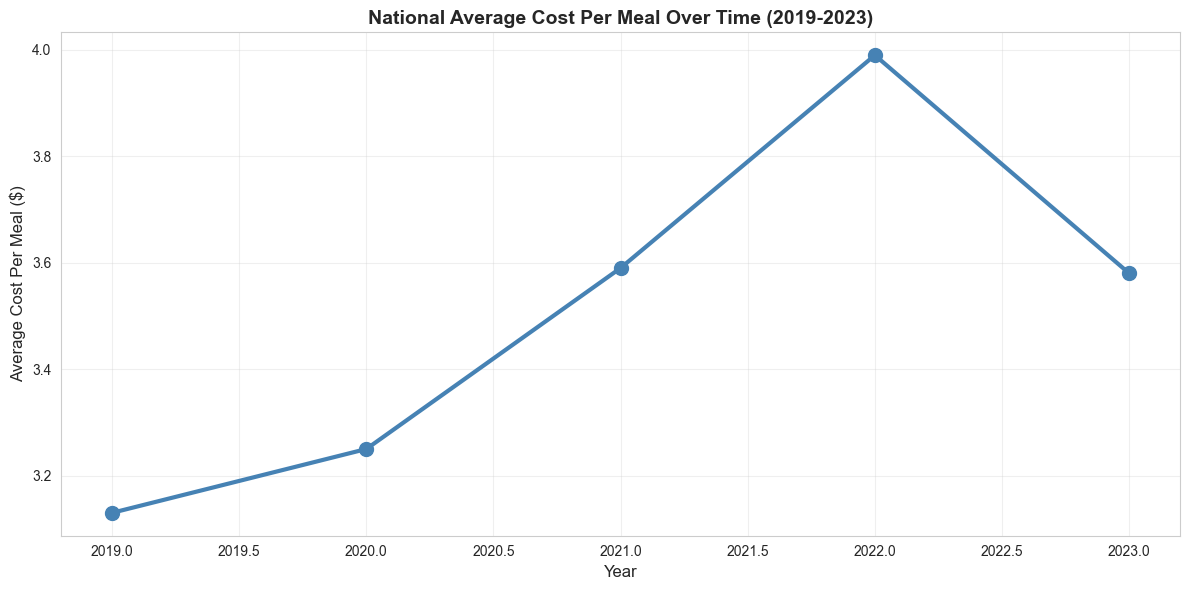

In [23]:
# Temporal trends visualization
plt.figure(figsize=(12, 6))
yearly_avg = df_food.groupby('Year')['Cost Per Meal'].mean()
plt.plot(yearly_avg.index, yearly_avg.values, marker='o', linewidth=3, markersize=10, color='steelblue')
plt.title('National Average Cost Per Meal Over Time (2019-2023)', fontsize=14, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Cost Per Meal ($)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

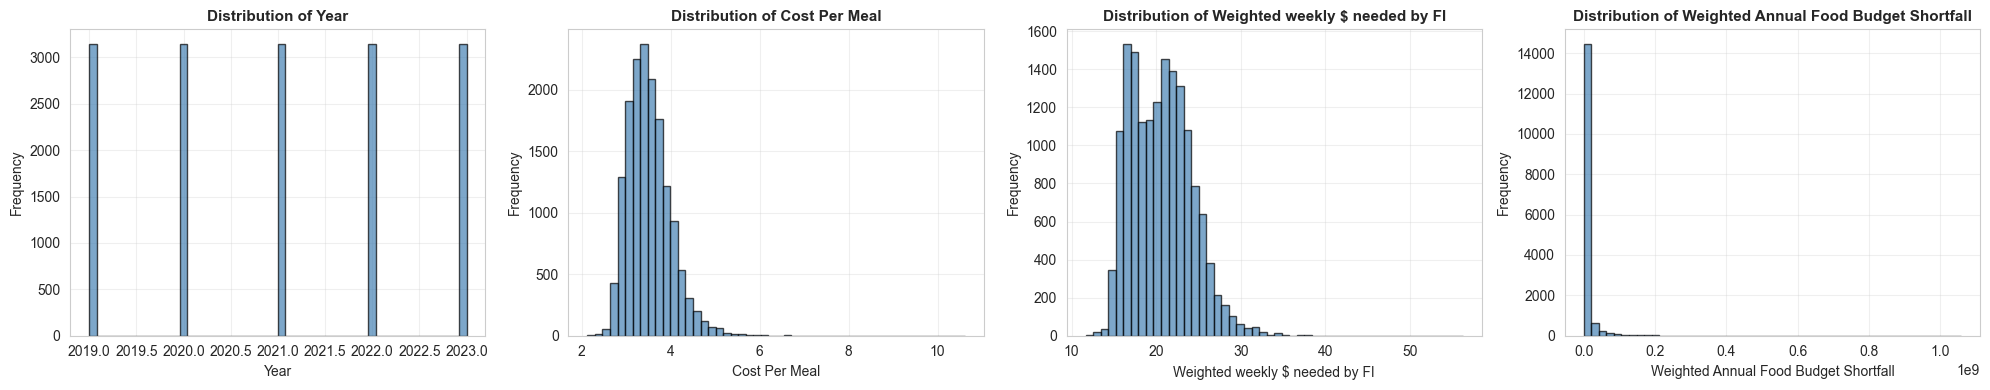

In [24]:
# Distribution plots
numeric_cols = df_food.select_dtypes(include=[np.number]).columns
create_distribution_plots(df_food, "Food_Costs", numeric_cols)

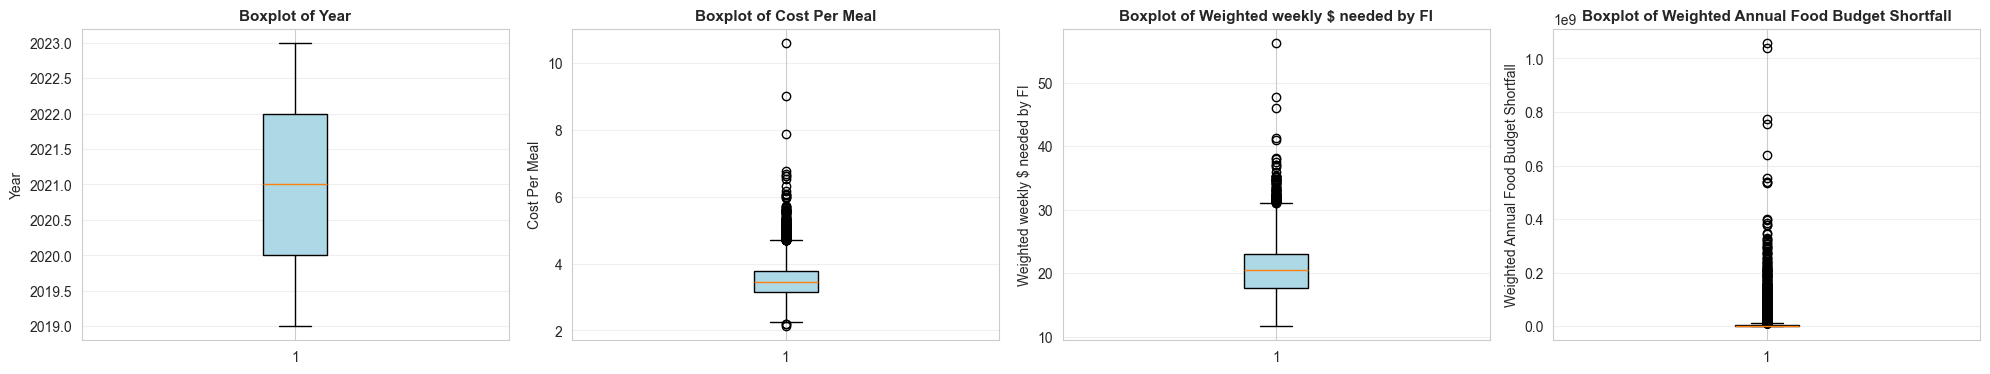

In [26]:
# Boxplots
create_boxplots(df_food, "Food_Costs", numeric_cols)


Food Costs - Correlation Analysis
------------------------------------------------------------

Correlation Matrix:


,Year,Cost Per Meal,Weighted weekly $ needed by FI,Weighted Annual Food Budget Shortfall
Year,1.00,0.48,0.67,0.06
Cost Per Meal,0.48,1.00,0.95,0.18
Weighted weekly $ needed by FI,0.67,0.95,1.00,0.17
Weighted Annual Food Budget Shortfall,0.06,0.18,0.17,1.00


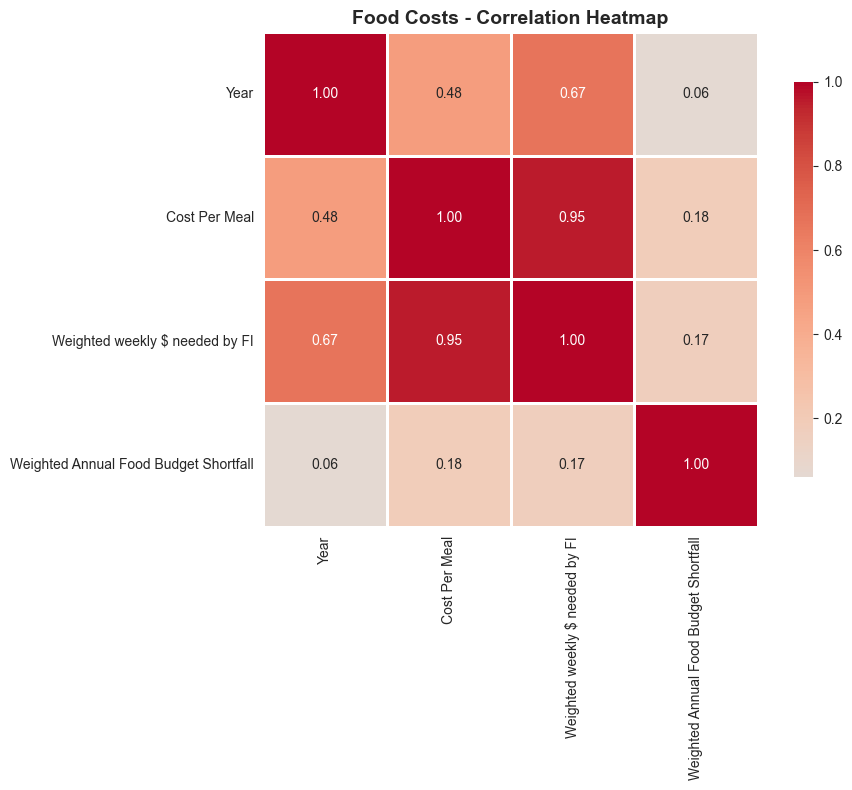



Highly Correlated Variable Pairs (|r| > 0.7):


,Variable 1,Variable 2,Correlation
0,Cost Per Meal,Weighted weekly $ needed by FI,0.95


In [28]:
# Correlation analysis
correlation_analysis(df_food, "Food Costs")

---
# Dataset 2: County Grocery Store Density

In [31]:
print_section_header("DATASET 2: COUNTY GROCERY STORE DENSITY")

# Load data
df_grocery = pd.read_csv(file_paths['grocery_density'])

# Basic Information
basic_info(df_grocery, "Grocery Density")


 DATASET 2: COUNTY GROCERY STORE DENSITY


Grocery Density - Basic Information
------------------------------------------------------------
Shape: (3144, 9)

Column Names and Types:
FIPS                   int64
State                 object
County                object
GROC16                 int64
GROC20                 int64
PCH_GROC_16_20       float64
GROCPTH16            float64
GROCPTH20            float64
PCH_GROCPTH_16_20    float64
dtype: object

First few rows:


,FIPS,State,County,GROC16,GROC20,PCH_GROC_16_20,GROCPTH16,GROCPTH20,PCH_GROCPTH_16_20
0,1001,AL,Autauga,3,4,33.33,0.05,0.07,31.33
1,1003,AL,Baldwin,29,29,0.00,0.14,0.13,-9.38
2,1005,AL,Barbour,4,5,25.00,0.15,0.20,31.30
3,1007,AL,Bibb,5,4,-20.00,0.22,0.18,-18.36
4,1009,AL,Blount,5,4,-20.00,0.09,0.07,-20.54


In [32]:
# Missing Value Analysis
missing_value_analysis(df_grocery, "Grocery Density")


Grocery Density - Missing Value Analysis
------------------------------------------------------------
✓ No missing values detected!


In [33]:
# Handle -9999 values
print("\n\nReplacing -9999 with NaN for analysis...")
df_grocery_clean = df_grocery.replace(-9999, np.nan)

# Statistical Summary
statistical_summary(df_grocery_clean, "Grocery Density")



Replacing -9999 with NaN for analysis...

Grocery Density - Statistical Summary
------------------------------------------------------------


,FIPS,GROC16,GROC20,PCH_GROC_16_20,GROCPTH16,GROCPTH20,PCH_GROCPTH_16_20
count,3144.00,3068.00,2235.00,2234.00,3068.00,2235.00,2234.00
mean,30365.63,15.52,23.32,-3.78,-5.54,-3.75,-4.60
std,15174.50,245.05,210.85,190.17,226.90,188.01,190.17
min,1001.00,-8888.00,-8888.00,-8888.00,-8888.00,-8888.00,-8888.00
25%,18174.50,3.00,4.00,-16.67,0.14,0.13,-16.40
50%,29174.00,5.00,7.00,0.00,0.19,0.18,-2.33
75%,45079.50,12.00,17.00,7.69,0.28,0.26,5.98
max,56045.00,2495.00,2019.00,300.00,3.25,2.34,330.34




Additional Statistics:
------------------------------------------------------------


,Variable,Skewness,Kurtosis,CV,IQR,Outliers,Outlier_%
0,FIPS,-0.08,-1.10,0.50,26905.00,0,0.00
1,GROC16,-30.46,1140.15,15.79,9.00,409,13.33
2,GROC20,-32.68,1434.29,9.04,13.00,290,12.98
3,PCH_GROC_16_20,-45.66,2130.97,-50.25,24.36,132,5.91
4,GROCPTH16,-39.13,1529.00,-40.95,0.15,243,7.92
5,GROCPTH20,-47.24,2230.00,-50.12,0.12,157,7.02
6,PCH_GROCPTH_16_20,-45.64,2130.17,-41.32,22.38,154,6.89


In [35]:
# Change analysis
print("\n\nGrocery Store Changes (2016-2020):")
print("-" * 60)

# Filter out counties with missing data
df_complete = df_grocery_clean.dropna(subset=['GROC16', 'GROC20'])

print(f"\nCounties with complete data: {len(df_complete)} out of {len(df_grocery)}")
print(f"\nAverage change in grocery stores: {df_complete['PCH_GROC_16_20'].mean():.2f}%")
print(f"Median change in grocery stores: {df_complete['PCH_GROC_16_20'].median():.2f}%")

# Counties with biggest increases/decreases
print("\n\nTop 10 Counties - Largest Increase in Grocery Stores:")
top_increase = df_complete.nlargest(10, 'PCH_GROC_16_20')[['State', 'County', 'GROC16', 'GROC20', 'PCH_GROC_16_20']]
display(top_increase)

print("\n\nTop 10 Counties - Largest Decrease in Grocery Stores:")
top_decrease = df_complete.nsmallest(10, 'PCH_GROC_16_20')[['State', 'County', 'GROC16', 'GROC20', 'PCH_GROC_16_20']]
display(top_decrease)



Grocery Store Changes (2016-2020):
------------------------------------------------------------

Counties with complete data: 2234 out of 3144

Average change in grocery stores: -3.78%
Median change in grocery stores: 0.00%


Top 10 Counties - Largest Increase in Grocery Stores:


,State,County,GROC16,GROC20,PCH_GROC_16_20
2010,ND,Grant,1.00,4.00,300.00
3054,WI,Buffalo,1.00,4.00,300.00
17,AL,Conecuh,1.00,3.00,200.00
388,FL,Washington,1.00,3.00,200.00
530,GA,Turner,1.00,3.00,200.00
537,GA,Warren,1.00,3.00,200.00
666,IL,Moultrie,1.00,3.00,200.00
705,IN,Brown,1.00,3.00,200.00
959,KS,Osage,1.00,3.00,200.00
2257,PA,Cameron,1.00,3.00,200.00




Top 10 Counties - Largest Decrease in Grocery Stores:


,State,County,GROC16,GROC20,PCH_GROC_16_20
94,AK,Valdez-Cordova,8.00,-8888.00,-8888.00
2275,PA,Greene,12.00,5.00,-58.33
65,AL,Wilcox,7.00,3.00,-57.14
1538,MO,Lafayette,7.00,3.00,-57.14
617,IL,Douglas,11.00,5.00,-54.55
1478,MS,Washington,11.00,5.00,-54.55
398,GA,Berrien,6.00,3.00,-50.00
428,GA,Crisp,14.00,7.00,-50.00
523,GA,Terrell,6.00,3.00,-50.00
536,GA,Ware,6.00,3.00,-50.00


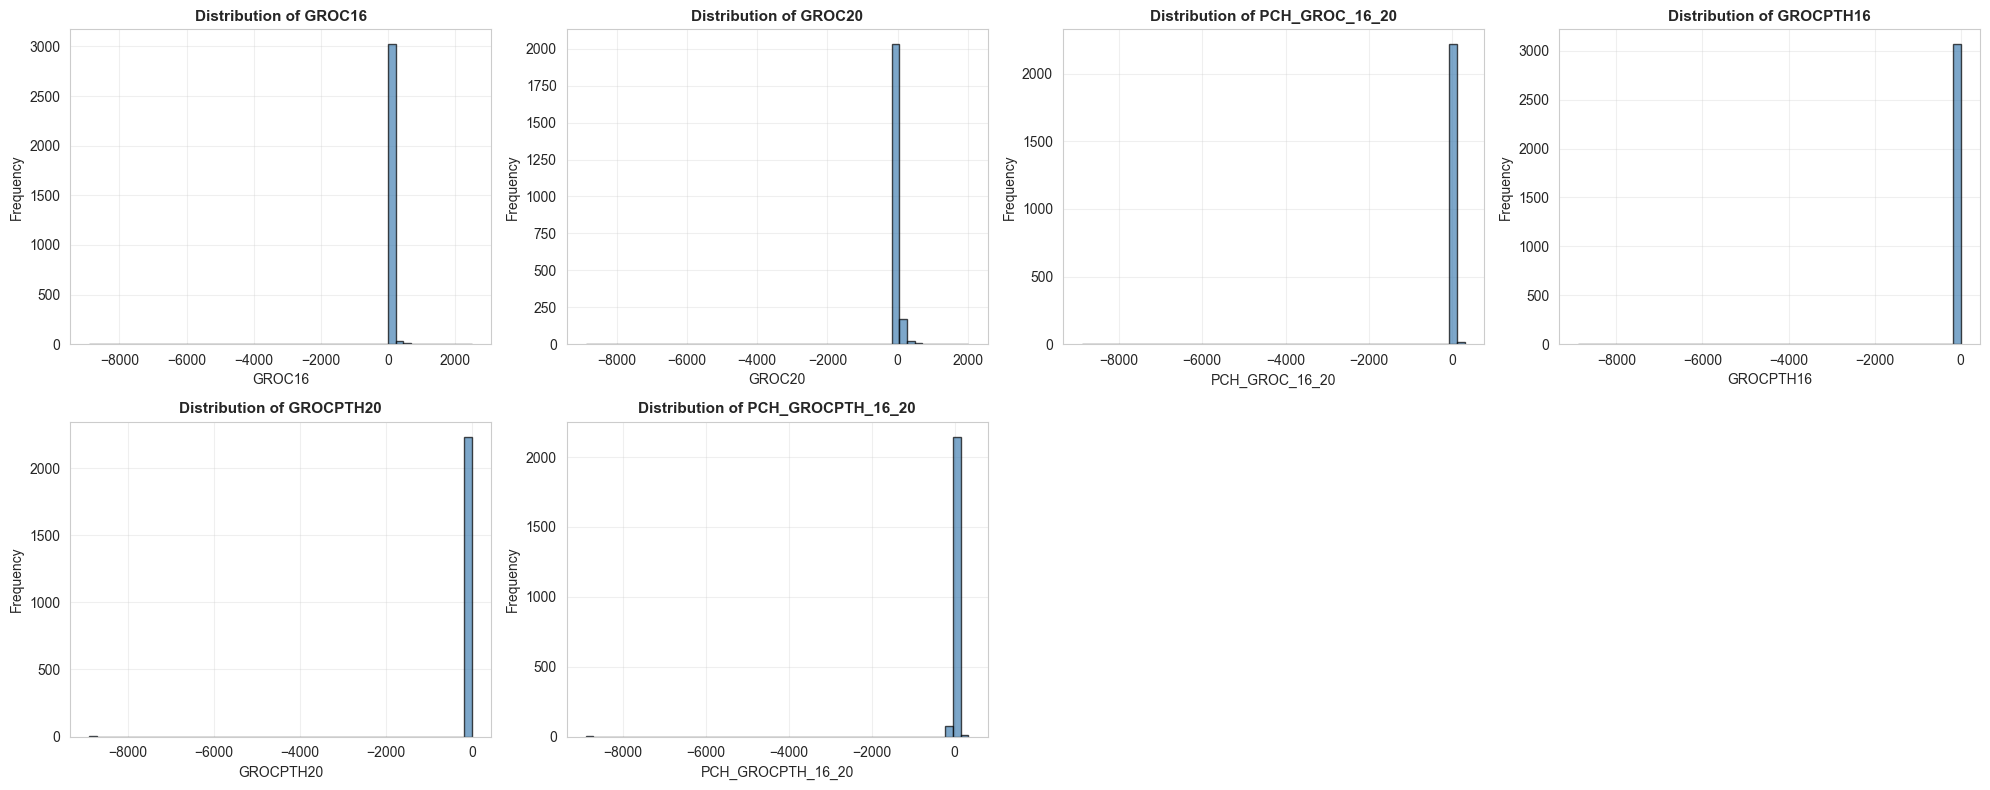

In [36]:
# Distribution plots
numeric_cols = df_grocery_clean.select_dtypes(include=[np.number]).columns
create_distribution_plots(df_grocery_clean, "Grocery_Density", numeric_cols)

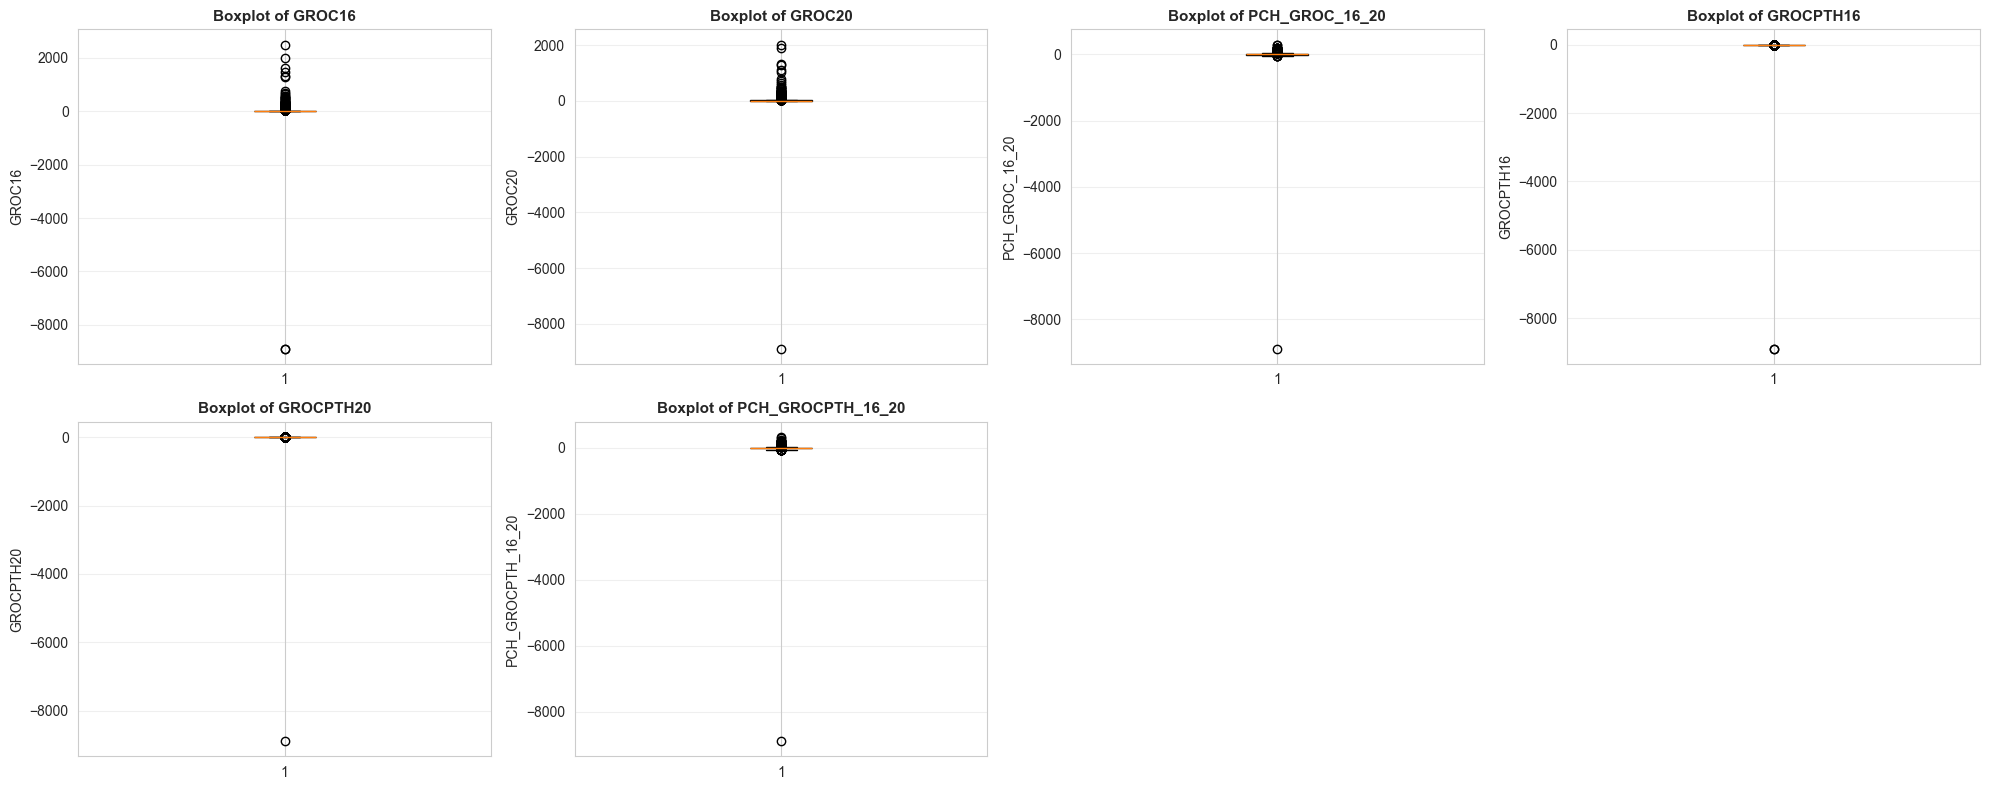

In [38]:
# Boxplots
create_boxplots(df_grocery_clean, "Grocery_Density", numeric_cols)


Grocery Density - Correlation Analysis
------------------------------------------------------------

Correlation Matrix:


,GROC16,GROC20,PCH_GROC_16_20,GROCPTH16,GROCPTH20,PCH_GROCPTH_16_20
GROC16,1.00,0.45,-0.00,0.93,0.00,-0.00
GROC20,0.45,1.00,0.88,-0.04,0.89,0.88
PCH_GROC_16_20,-0.00,0.88,1.00,-0.10,0.99,1.00
GROCPTH16,0.93,-0.04,-0.10,1.00,-0.08,-0.09
GROCPTH20,0.00,0.89,0.99,-0.08,1.00,0.99
PCH_GROCPTH_16_20,-0.00,0.88,1.00,-0.09,0.99,1.00


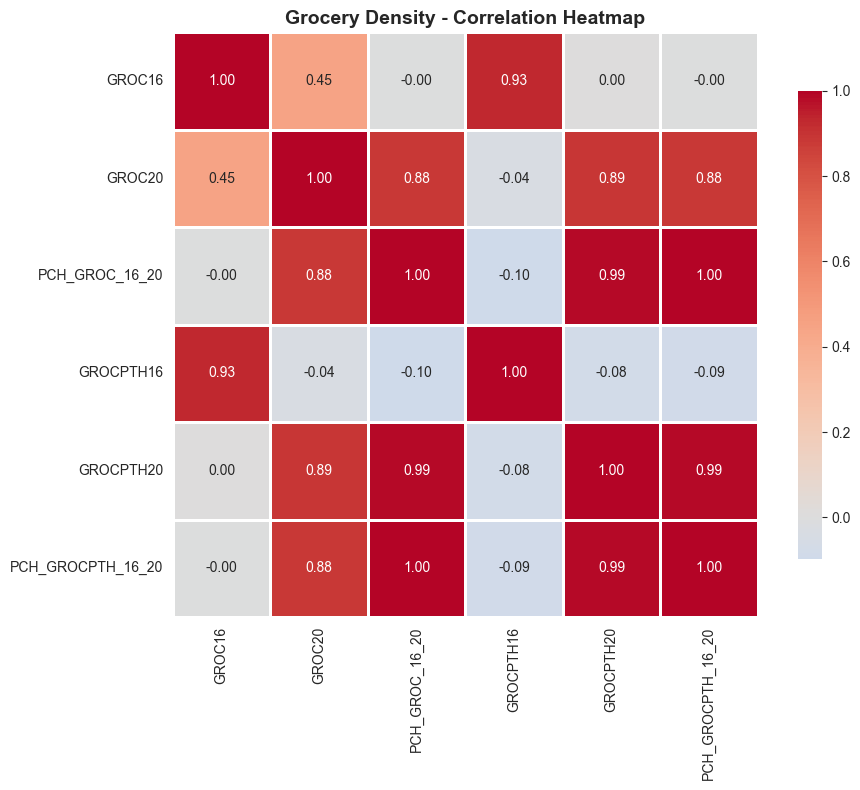



Highly Correlated Variable Pairs (|r| > 0.7):


,Variable 1,Variable 2,Correlation
5,PCH_GROC_16_20,PCH_GROCPTH_16_20,1.00
4,PCH_GROC_16_20,GROCPTH20,0.99
6,GROCPTH20,PCH_GROCPTH_16_20,0.99
0,GROC16,GROCPTH16,0.93
2,GROC20,GROCPTH20,0.89
1,GROC20,PCH_GROC_16_20,0.88
3,GROC20,PCH_GROCPTH_16_20,0.88


In [41]:
# Correlation analysis
correlation_analysis(df_grocery_clean, "Grocery Density")

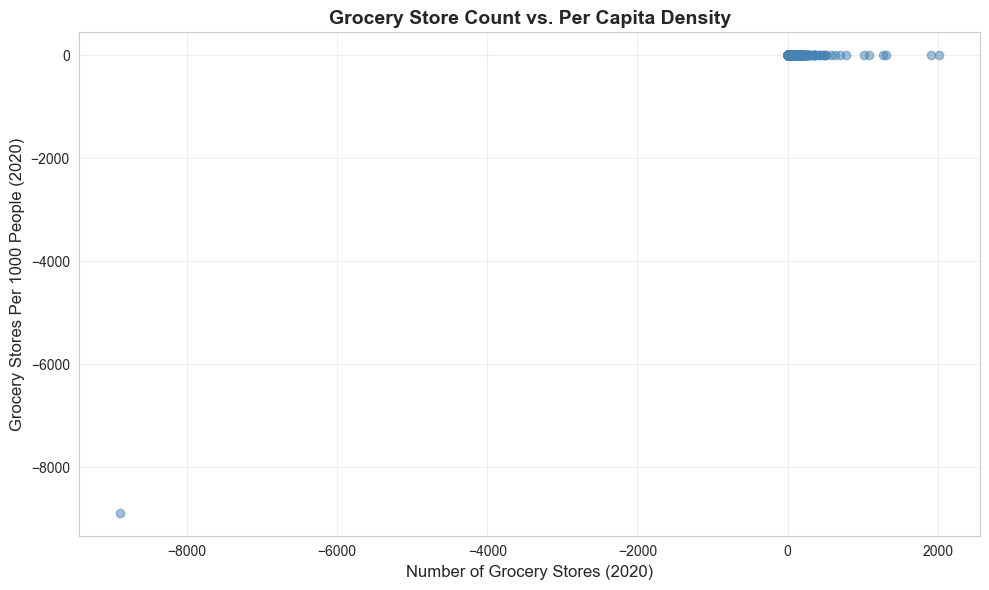

In [43]:
# Scatter plot: Absolute vs Per Capita density
plt.figure(figsize=(10, 6))
plt.scatter(df_grocery_clean['GROC20'], df_grocery_clean['GROCPTH20'], alpha=0.5, color='steelblue')
plt.xlabel('Number of Grocery Stores (2020)', fontsize=12)
plt.ylabel('Grocery Stores Per 1000 People (2020)', fontsize=12)
plt.title('Grocery Store Count vs. Per Capita Density', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Dataset 3: County Median Household Income

In [46]:
print_section_header("DATASET 3: COUNTY MEDIAN HOUSEHOLD INCOME")

# Load data
df_income = pd.read_csv(file_paths['median_income'])

# Convert numeric columns from string to float
numeric_cols_to_convert = ['Median_Household_Income', 'Median_Income_Lower_Bound', 'Median_Income_Upper_Bound']
for col in numeric_cols_to_convert:
    df_income[col] = pd.to_numeric(df_income[col], errors='coerce')

# Basic Information
basic_info(df_income, "Median Income")


 DATASET 3: COUNTY MEDIAN HOUSEHOLD INCOME


Median Income - Basic Information
------------------------------------------------------------
Shape: (3196, 5)

Column Names and Types:
FIPS                           int64
Name                          object
Median_Household_Income      float64
Median_Income_Lower_Bound    float64
Median_Income_Upper_Bound    float64
dtype: object

First few rows:


,FIPS,Name,Median_Household_Income,Median_Income_Lower_Bound,Median_Income_Upper_Bound
0,0,United States,77719.00,77533.00,77905.00
1,1000,Alabama,62248.00,61546.00,62950.00
2,1001,Autauga County,68857.00,62667.00,75047.00
3,1003,Baldwin County,74248.00,69046.00,79450.00
4,1005,Barbour County,45298.00,40531.00,50065.00


In [47]:
# Missing Value Analysis
missing_value_analysis(df_income, "Median Income")


Median Income - Missing Value Analysis
------------------------------------------------------------


,Missing_Count,Missing_Percentage
Median_Household_Income,1,0.03
Median_Income_Lower_Bound,1,0.03
Median_Income_Upper_Bound,1,0.03



Checking for -9999 (common missing indicator):


In [48]:
# Statistical Summary
statistical_summary(df_income, "Median Income")


Median Income - Statistical Summary
------------------------------------------------------------


,FIPS,Median_Household_Income,Median_Income_Lower_Bound,Median_Income_Upper_Bound
count,3196.00,3195.00,3195.00,3195.00
mean,30336.23,65757.50,60014.54,71500.46
std,15186.78,16555.77,16352.23,16978.21
min,0.00,28579.00,25831.00,31327.00
25%,18168.50,54744.00,48992.50,60193.00
50%,29172.00,63084.00,57253.00,68852.00
75%,45073.50,73299.50,67426.50,79352.50
max,56045.00,173655.00,166719.00,180591.00




Additional Statistics:
------------------------------------------------------------


,Variable,Skewness,Kurtosis,CV,IQR,Outliers,Outlier_%
0,FIPS,-0.08,-1.10,0.50,26905.00,0,0.00
1,Median_Household_Income,1.33,3.20,0.25,18555.50,127,3.97
2,Median_Income_Lower_Bound,1.37,3.24,0.27,18434.00,130,4.07
3,Median_Income_Upper_Bound,1.30,3.19,0.24,19159.50,121,3.79


In [49]:
# Confidence interval analysis
print("\n\nConfidence Interval Analysis:")
print("-" * 60)
df_income['CI_Width'] = df_income['Median_Income_Upper_Bound'] - df_income['Median_Income_Lower_Bound']
print(f"Average CI Width: ${df_income['CI_Width'].mean():.2f}")
print(f"Median CI Width: ${df_income['CI_Width'].median():.2f}")



Confidence Interval Analysis:
------------------------------------------------------------
Average CI Width: $11485.92
Median CI Width: $11494.00


In [50]:
# Income distribution by state
print("\n\nState-Level Income Statistics:")
print("-" * 60)

# Filter state-level rows (FIPS ending in 000)
df_income['FIPS_str'] = df_income['FIPS'].astype(str).str.zfill(5)
state_rows = df_income[df_income['FIPS_str'].str.endswith('000')]

if len(state_rows) > 0:
    print("\nTop 10 States by Median Household Income:")
    top_states = state_rows.nlargest(10, 'Median_Household_Income')[['Name', 'Median_Household_Income']]
    display(top_states)
    
    print("\n\nBottom 10 States by Median Household Income:")
    bottom_states = state_rows.nsmallest(10, 'Median_Household_Income')[['Name', 'Median_Household_Income']]
    display(bottom_states)



State-Level Income Statistics:
------------------------------------------------------------

Top 10 States by Median Household Income:


,Name,Median_Household_Income
330,District of Columbia,104643.00
1241,Massachusetts,99750.00
1807,New Jersey,99716.00
1216,Maryland,98568.00
1796,New Hampshire,97031.00
560,Hawaii,96716.00
192,California,95473.00
3003,Washington,94553.00
2824,Utah,93030.00
251,Colorado,92790.00




Bottom 10 States by Median Household Income:


,Name,Median_Household_Income
1428,Mississippi,54386.00
3043,West Virginia,55875.00
1134,Louisiana,58273.00
116,Arkansas,58748.00
1013,Kentucky,61099.00
2170,Oklahoma,62120.00
1,Alabama,62248.00
1829,New Mexico,62286.00
2473,Tennessee,67651.00
2081,Ohio,67873.00


In [51]:
# County-level analysis
county_rows = df_income[~df_income['FIPS_str'].str.endswith('000')]

print("\n\nTop 10 Counties by Median Household Income:")
top_counties = county_rows.nlargest(10, 'Median_Household_Income')[['Name', 'Median_Household_Income']]
display(top_counties)

print("\n\nBottom 10 Counties by Median Household Income:")
bottom_counties = county_rows.nsmallest(10, 'Median_Household_Income')[['Name', 'Median_Household_Income']]
display(bottom_counties)



Top 10 Counties by Median Household Income:


,Name,Median_Household_Income
2922,Loudoun County,173655.00
235,Santa Clara County,154573.00
233,San Mateo County,151004.00
1845,Los Alamos County,146208.00
2975,Falls Church city,145755.00
270,Douglas County,144807.00
2898,Fairfax County,141353.00
1893,Nassau County,140466.00
1825,Somerset County,140242.00
1229,Howard County,140113.00




Bottom 10 Counties by Median Household Income:


,Name,Median_Household_Income
1439,Claiborne County,28579.00
1454,Holmes County,30542.00
1455,Humphreys County,31538.00
2414,Buffalo County,32803.00
1470,Leflore County,33945.00
54,Perry County,34176.00
67,Wilcox County,34426.00
1152,East Carroll Parish,34604.00
33,Greene County,34619.00
1167,Madison Parish,34704.00


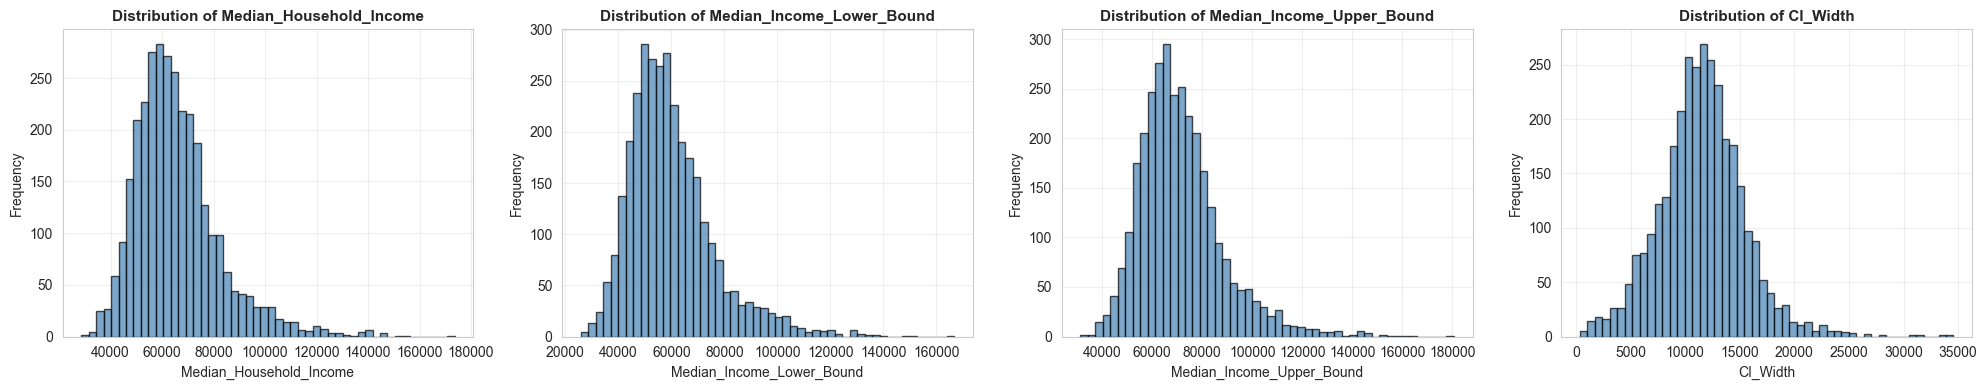

In [53]:
# Distribution plots
numeric_cols = df_income.select_dtypes(include=[np.number]).columns
create_distribution_plots(df_income, "Median_Income", numeric_cols)

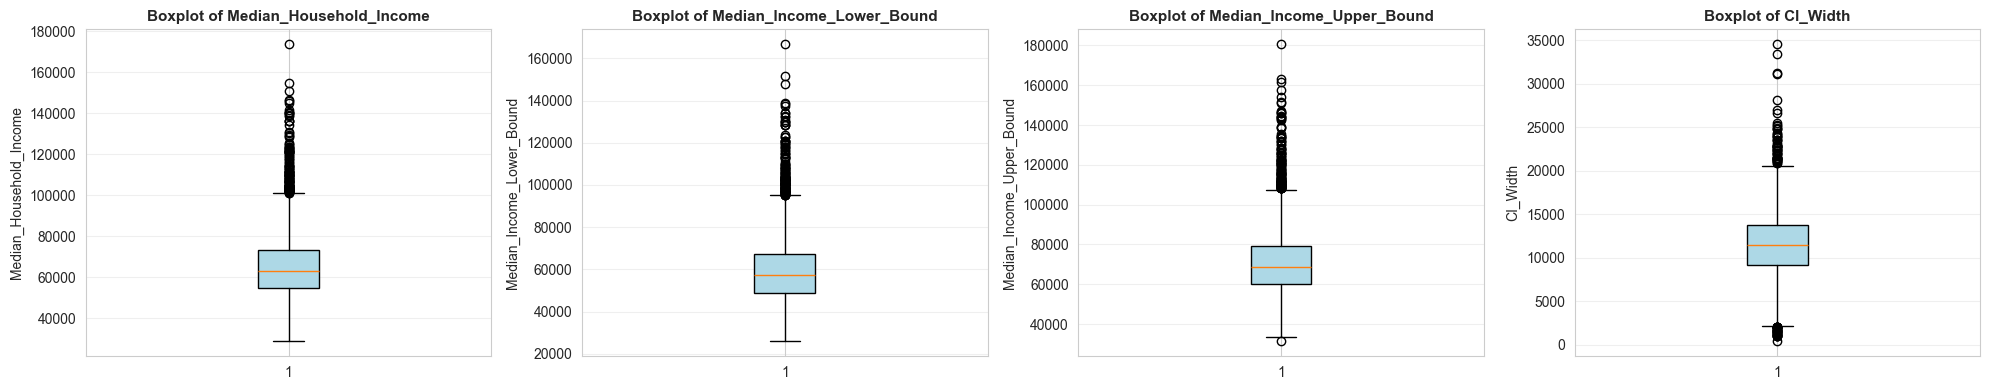

In [54]:
# Boxplots
create_boxplots(df_income, "Median_Income", numeric_cols)


Median Income - Correlation Analysis
------------------------------------------------------------

Correlation Matrix:


,Median_Household_Income,Median_Income_Lower_Bound,Median_Income_Upper_Bound,CI_Width
Median_Household_Income,1.00,0.99,0.99,0.16
Median_Income_Lower_Bound,0.99,1.00,0.97,0.05
Median_Income_Upper_Bound,0.99,0.97,1.00,0.27
CI_Width,0.16,0.05,0.27,1.00


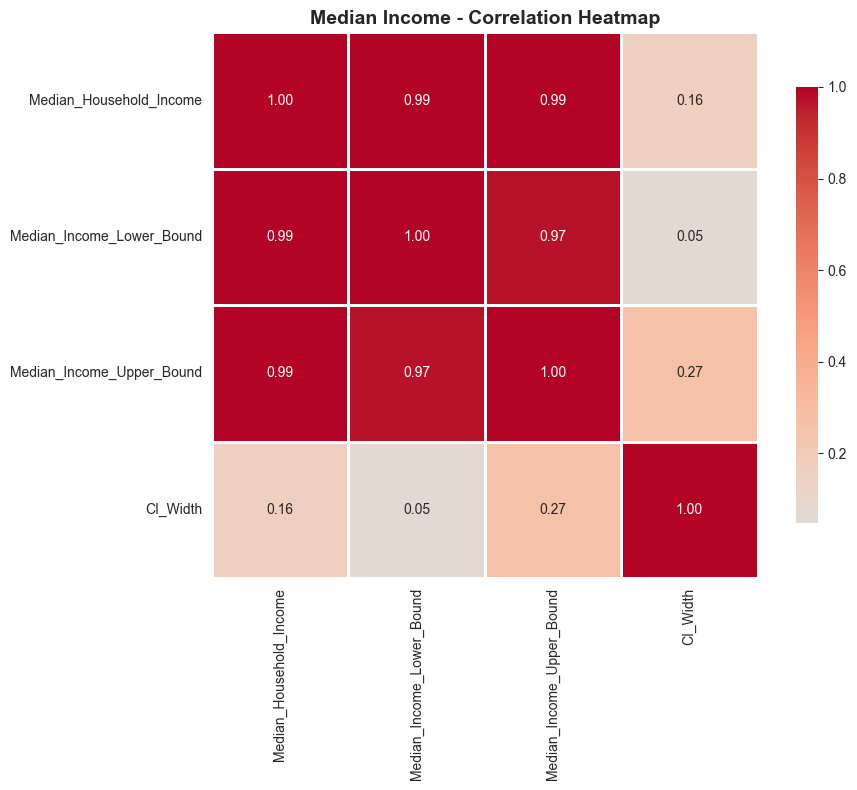



Highly Correlated Variable Pairs (|r| > 0.7):


,Variable 1,Variable 2,Correlation
1,Median_Household_Income,Median_Income_Upper_Bound,0.99
0,Median_Household_Income,Median_Income_Lower_Bound,0.99
2,Median_Income_Lower_Bound,Median_Income_Upper_Bound,0.97


In [55]:
# Correlation analysis
correlation_analysis(df_income, "Median Income")

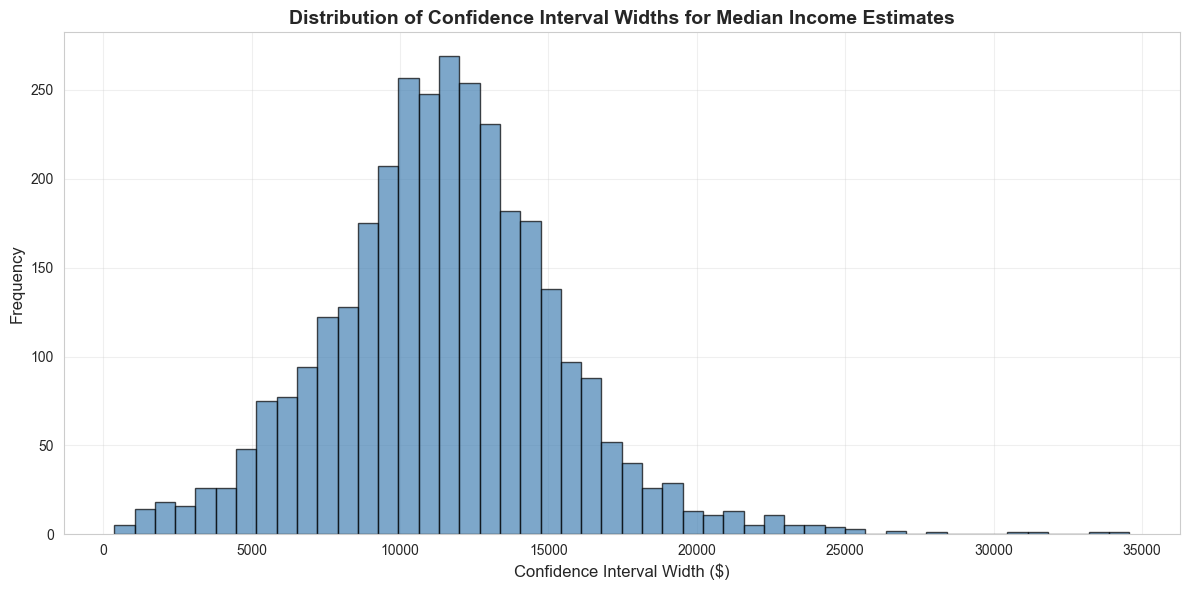

In [56]:
# Visualization of confidence intervals
plt.figure(figsize=(12, 6))
plt.hist(df_income['CI_Width'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('Confidence Interval Width ($)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Confidence Interval Widths for Median Income Estimates', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Dataset 4: Medicare Cost Per Capita (2023)

In [59]:
print_section_header("DATASET 4: MEDICARE COST PER CAPITA (2023)")

# Load data
df_medicare = pd.read_csv(file_paths['medicare_costs'])

# Convert numeric columns from string to appropriate types
numeric_cols_to_convert = ['BENES_TOTAL_CNT', 'BENE_AVG_AGE', 'BENE_AVG_RISK_SCRE', 
                            'TOT_MDCR_PYMT_PC', 'TOT_MDCR_STDZD_PYMT_PC']
for col in numeric_cols_to_convert:
    df_medicare[col] = pd.to_numeric(df_medicare[col], errors='coerce')

# Basic Information
basic_info(df_medicare, "Medicare Costs")


 DATASET 4: MEDICARE COST PER CAPITA (2023)


Medicare Costs - Basic Information
------------------------------------------------------------
Shape: (3198, 9)

Column Names and Types:
YEAR                        int64
BENE_GEO_DESC              object
BENE_GEO_CD               float64
BENE_AGE_LVL               object
BENES_TOTAL_CNT           float64
BENE_AVG_AGE              float64
BENE_AVG_RISK_SCRE        float64
TOT_MDCR_PYMT_PC          float64
TOT_MDCR_STDZD_PYMT_PC    float64
dtype: object

First few rows:


,YEAR,BENE_GEO_DESC,BENE_GEO_CD,BENE_AGE_LVL,BENES_TOTAL_CNT,BENE_AVG_AGE,BENE_AVG_RISK_SCRE,TOT_MDCR_PYMT_PC,TOT_MDCR_STDZD_PYMT_PC
0,2023,AK-Aleutians East,2013.00,All,171.00,72.00,0.89,11214.05,7913.45
1,2023,AK-Aleutians West,2016.00,All,250.00,72.00,0.72,9465.64,8125.52
2,2023,AK-Anchorage,2020.00,All,45726.00,71.00,0.88,11173.35,9192.93
3,2023,AK-Bethel,2050.00,All,1748.00,71.00,0.79,11616.80,8116.22
4,2023,AK-Bristol Bay,2060.00,All,181.00,73.00,0.83,15873.30,10405.53


In [60]:
# Missing Value Analysis
missing_value_analysis(df_medicare, "Medicare Costs")


Medicare Costs - Missing Value Analysis
------------------------------------------------------------


,Missing_Count,Missing_Percentage
BENES_TOTAL_CNT,52,1.63
BENE_AVG_AGE,52,1.63
BENE_AVG_RISK_SCRE,52,1.63
TOT_MDCR_PYMT_PC,52,1.63
TOT_MDCR_STDZD_PYMT_PC,52,1.63



Checking for -9999 (common missing indicator):


In [62]:
# Statistical Summary
statistical_summary(df_medicare, "Medicare Costs")


Medicare Costs - Statistical Summary
------------------------------------------------------------


,YEAR,BENE_GEO_CD,BENES_TOTAL_CNT,BENE_AVG_AGE,BENE_AVG_RISK_SCRE,TOT_MDCR_PYMT_PC,TOT_MDCR_STDZD_PYMT_PC
count,3198.00,3198.00,3146.00,3146.00,3146.00,3146.00,3146.00
mean,2023.00,30411.39,21660.56,72.73,0.96,11915.18,11649.66
std,0.00,15261.98,58815.24,1.24,0.10,1897.45,1897.12
min,2023.00,1000.00,15.00,66.00,0.48,5936.40,5332.91
25%,2023.00,18173.50,2763.25,72.00,0.89,10705.45,10458.26
50%,2023.00,29178.00,6536.50,73.00,0.96,11639.28,11470.76
75%,2023.00,45080.50,16905.00,74.00,1.02,12843.40,12646.99
max,2023.00,78030.00,1678944.00,77.00,1.74,26685.09,27129.01




Additional Statistics:
------------------------------------------------------------


,Variable,Skewness,Kurtosis,CV,IQR,Outliers,Outlier_%
0,YEAR,NaN,NaN,0.00,0.00,0,0.00
1,BENE_GEO_CD,-0.05,-1.02,0.50,26907.00,0,0.00
2,BENES_TOTAL_CNT,11.73,242.08,2.72,14141.75,389,12.36
3,BENE_AVG_AGE,-0.64,1.88,0.02,2.00,21,0.67
4,BENE_AVG_RISK_SCRE,0.13,1.93,0.11,0.13,59,1.88
5,TOT_MDCR_PYMT_PC,1.33,5.09,0.16,2137.95,101,3.21
6,TOT_MDCR_STDZD_PYMT_PC,0.93,3.73,0.16,2188.73,95,3.02


In [63]:
# Age level analysis
print("\n\nAge Level Distribution:")
print("-" * 60)
display(df_medicare['BENE_AGE_LVL'].value_counts())

# Focus on 'All' age level for county comparisons
df_medicare_all = df_medicare[df_medicare['BENE_AGE_LVL'] == 'All'].copy()

print(f"\n\nAnalyzing 'All' age level data: {len(df_medicare_all)} counties")



Age Level Distribution:
------------------------------------------------------------


BENE_AGE_LVL
All    3198
Name: count, dtype: int64



Analyzing 'All' age level data: 3198 counties


In [64]:
# Beneficiary statistics
print("\n\nBeneficiary Statistics:")
print("-" * 60)
total_benes = df_medicare_all['BENES_TOTAL_CNT'].sum()
avg_benes = df_medicare_all['BENES_TOTAL_CNT'].mean()
median_benes = df_medicare_all['BENES_TOTAL_CNT'].median()
print(f"Total beneficiaries: {total_benes:,.0f}")
print(f"Average beneficiaries per county: {avg_benes:.0f}")
print(f"Median beneficiaries per county: {median_benes:.0f}")



Beneficiary Statistics:
------------------------------------------------------------
Total beneficiaries: 68,144,116
Average beneficiaries per county: 21661
Median beneficiaries per county: 6536


In [66]:
# Cost analysis
print("\n\nMedicare Cost Per Capita Analysis:")
print("-" * 60)
print(f"Mean Total Payment Per Capita: ${df_medicare_all['TOT_MDCR_PYMT_PC'].mean():.2f}")
print(f"Median Total Payment Per Capita: ${df_medicare_all['TOT_MDCR_PYMT_PC'].median():.2f}")
print(f"Mean Standardized Payment Per Capita: ${df_medicare_all['TOT_MDCR_STDZD_PYMT_PC'].mean():.2f}")
print(f"Median Standardized Payment Per Capita: ${df_medicare_all['TOT_MDCR_STDZD_PYMT_PC'].median():.2f}")

# Top/Bottom counties by cost
print("\n\nTop 10 Counties by Total Medicare Payment Per Capita:")
top_cost = df_medicare_all.nlargest(10, 'TOT_MDCR_PYMT_PC')[['BENE_GEO_DESC', 'TOT_MDCR_PYMT_PC', 'BENES_TOTAL_CNT']]
display(top_cost)

print("\n\nBottom 10 Counties by Total Medicare Payment Per Capita:")
bottom_cost = df_medicare_all.nsmallest(10, 'TOT_MDCR_PYMT_PC')[['BENE_GEO_DESC', 'TOT_MDCR_PYMT_PC', 'BENES_TOTAL_CNT']]
display(bottom_cost)



Medicare Cost Per Capita Analysis:
------------------------------------------------------------
Mean Total Payment Per Capita: $11915.18
Median Total Payment Per Capita: $11639.28
Mean Standardized Payment Per Capita: $11649.66
Median Standardized Payment Per Capita: $11470.76


Top 10 Counties by Total Medicare Payment Per Capita:


,BENE_GEO_DESC,TOT_MDCR_PYMT_PC,BENES_TOTAL_CNT
20,AK-North Slope,26685.09,605.00
942,KS-Hamilton,26351.54,432.00
497,GA-Miller,25168.13,1531.00
2454,SD-Oglala Lakota,24065.95,1431.00
21,AK-Northwest Arctic,22037.47,659.00
2195,OK-Greer,21356.01,1278.00
2798,TX-Upton,20487.33,680.00
2632,TX-Duval,20395.55,2487.00
2717,TX-Loving,20379.40,15.00
972,KS-Ness,20300.40,852.00




Bottom 10 Counties by Total Medicare Payment Per Capita:


,BENE_GEO_DESC,TOT_MDCR_PYMT_PC,BENES_TOTAL_CNT
1647,MT-Judith Basin,5936.40,667.00
1786,ND-Billings,6173.41,204.00
6,AK-Copper River,6345.71,239.00
2988,VI-St. Thomas,6512.70,10194.00
2986,VI-St. Croix,6668.63,10428.00
1839,NE-Arthur,6677.45,105.00
674,ID-Boundary,6731.12,4024.00
2433,SD-Hanson,6845.63,1184.00
2838,UT-Rich,7136.99,515.00
305,CO-Saguache,7258.21,1676.00


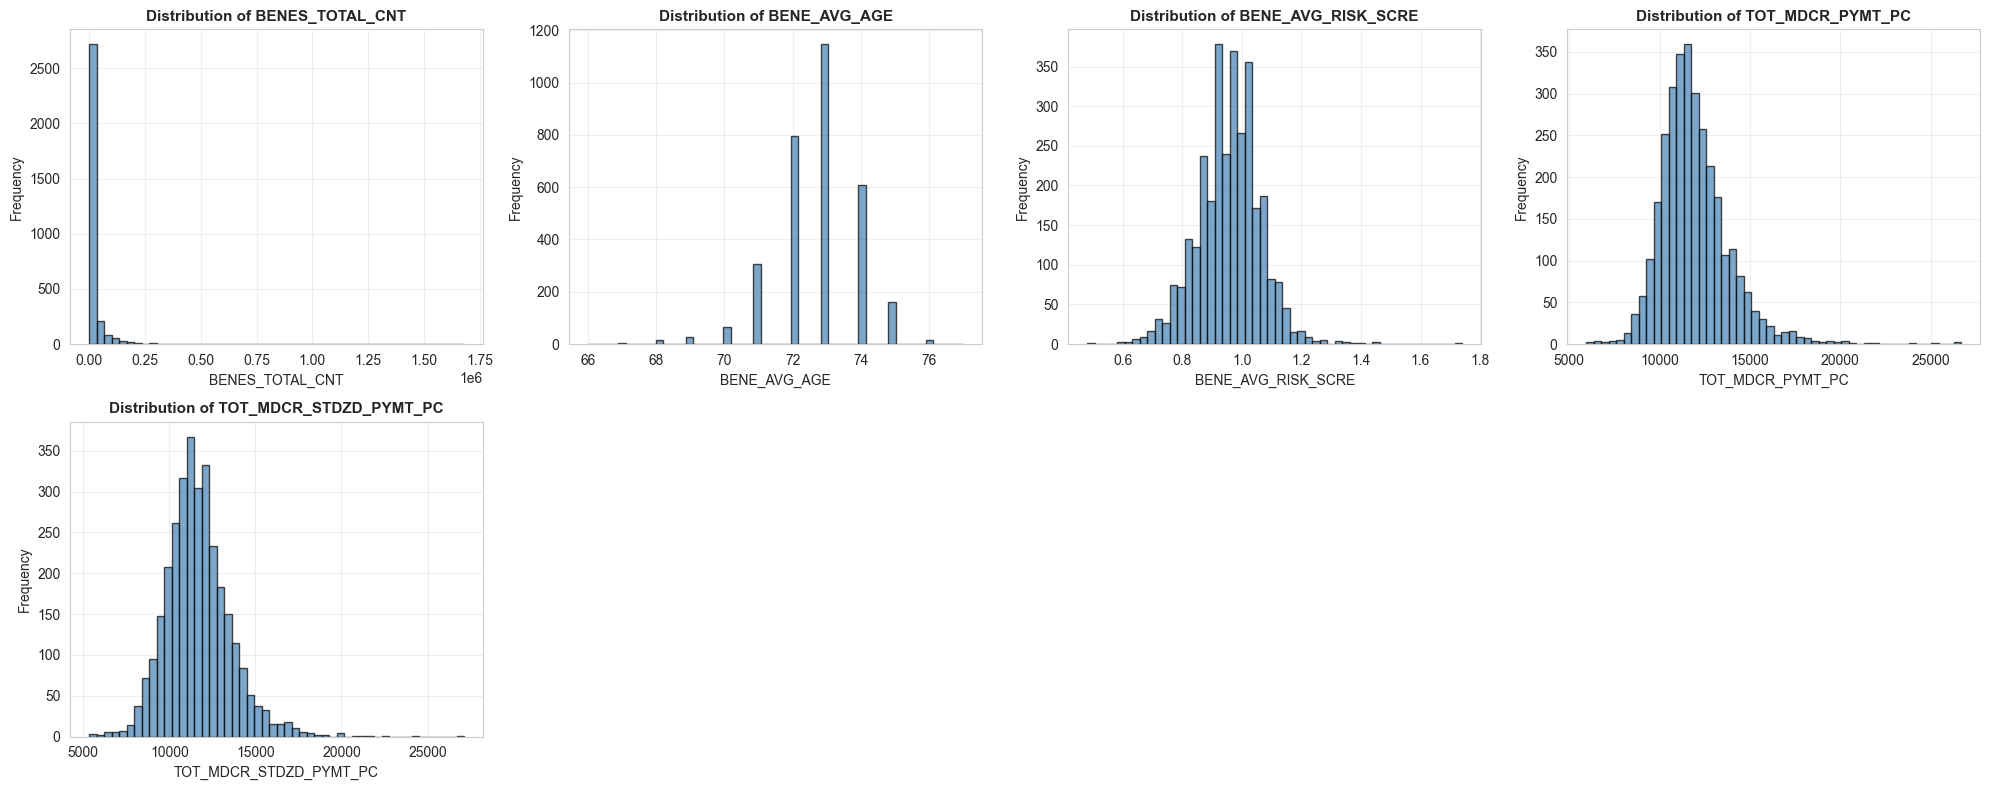

In [69]:
# Distribution plots
numeric_cols = df_medicare_all.select_dtypes(include=[np.number]).columns
create_distribution_plots(df_medicare_all, "Medicare_Costs", numeric_cols)

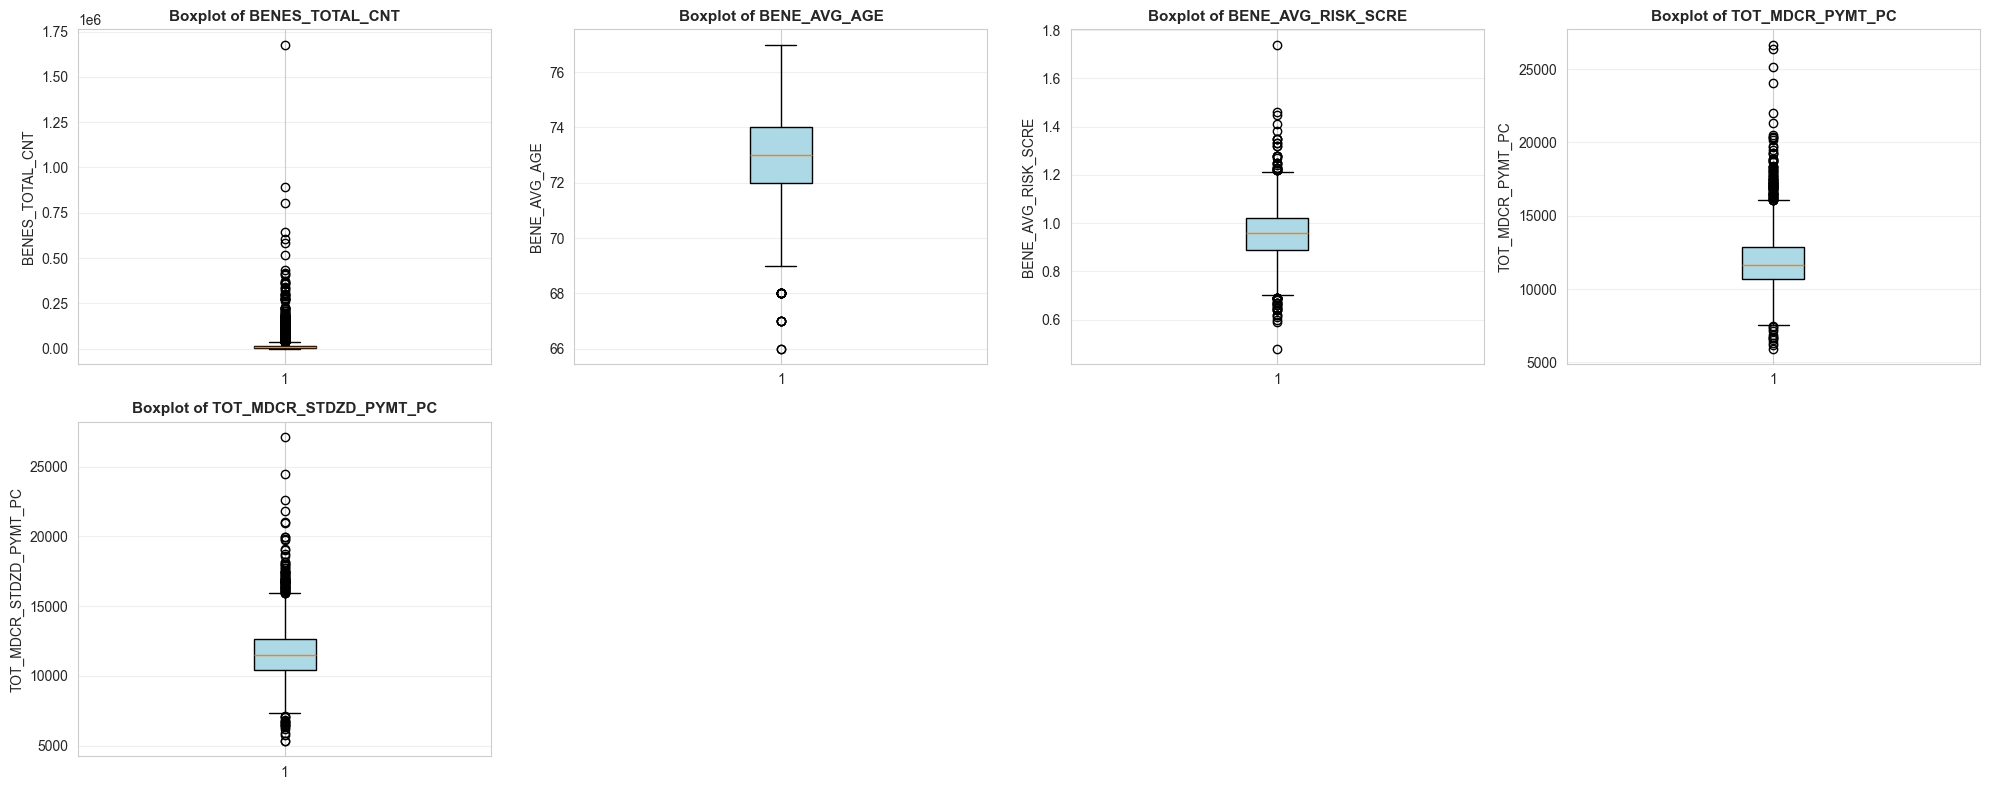

In [74]:
# Boxplots
create_boxplots(df_medicare_all, "Medicare_Costs", numeric_cols)


Medicare Costs - Correlation Analysis
------------------------------------------------------------

Correlation Matrix:


,BENES_TOTAL_CNT,BENE_AVG_AGE,BENE_AVG_RISK_SCRE,TOT_MDCR_PYMT_PC,TOT_MDCR_STDZD_PYMT_PC
BENES_TOTAL_CNT,1.00,0.06,0.21,0.20,0.07
BENE_AVG_AGE,0.06,1.00,-0.28,0.11,0.07
BENE_AVG_RISK_SCRE,0.21,-0.28,1.00,0.42,0.52
TOT_MDCR_PYMT_PC,0.20,0.11,0.42,1.00,0.90
TOT_MDCR_STDZD_PYMT_PC,0.07,0.07,0.52,0.90,1.00


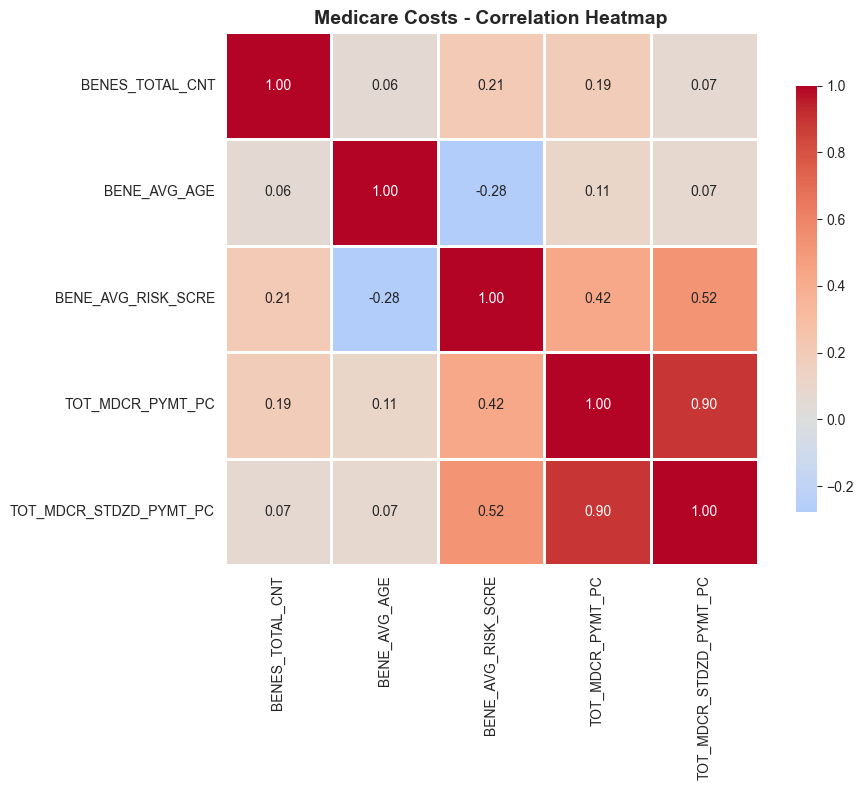



Highly Correlated Variable Pairs (|r| > 0.7):


,Variable 1,Variable 2,Correlation
0,TOT_MDCR_PYMT_PC,TOT_MDCR_STDZD_PYMT_PC,0.90


In [75]:
# Correlation analysis
correlation_analysis(df_medicare_all, "Medicare Costs")

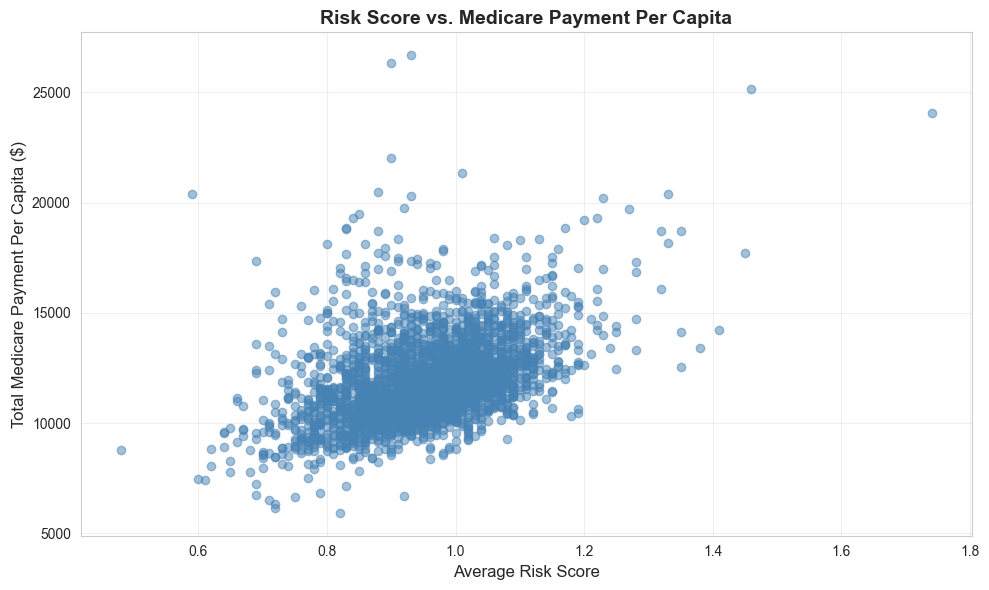

In [76]:
# Scatter plot: Risk Score vs Payment
plt.figure(figsize=(10, 6))
plt.scatter(df_medicare_all['BENE_AVG_RISK_SCRE'], df_medicare_all['TOT_MDCR_PYMT_PC'], alpha=0.5, color='steelblue')
plt.xlabel('Average Risk Score', fontsize=12)
plt.ylabel('Total Medicare Payment Per Capita ($)', fontsize=12)
plt.title('Risk Score vs. Medicare Payment Per Capita', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

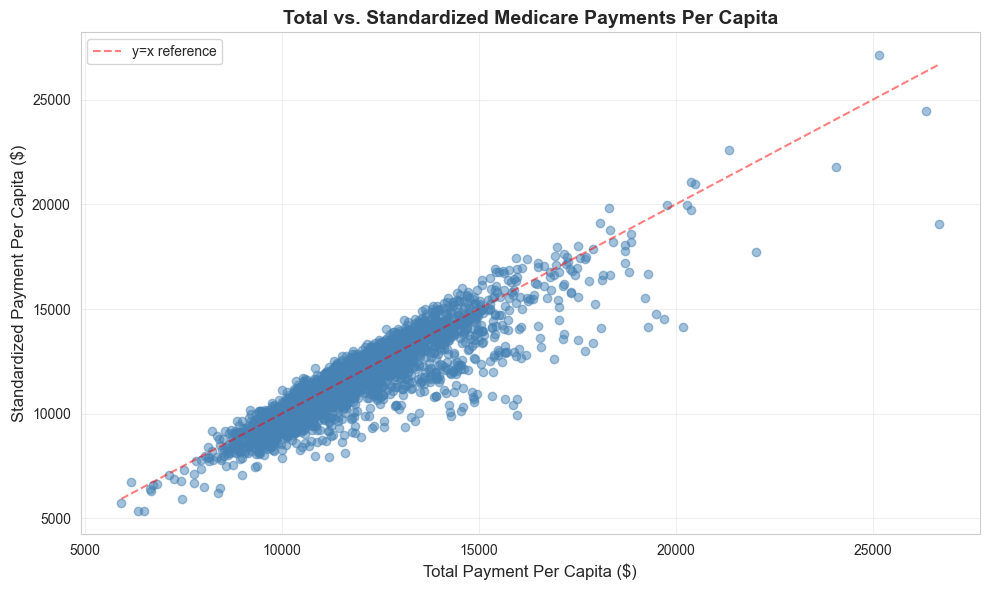

In [77]:
# Standardized vs Non-standardized comparison
plt.figure(figsize=(10, 6))
plt.scatter(df_medicare_all['TOT_MDCR_PYMT_PC'], df_medicare_all['TOT_MDCR_STDZD_PYMT_PC'], alpha=0.5, color='steelblue')
plt.xlabel('Total Payment Per Capita ($)', fontsize=12)
plt.ylabel('Standardized Payment Per Capita ($)', fontsize=12)
plt.title('Total vs. Standardized Medicare Payments Per Capita', fontsize=14, fontweight='bold')
x_range = [df_medicare_all['TOT_MDCR_PYMT_PC'].min(), df_medicare_all['TOT_MDCR_PYMT_PC'].max()]
plt.plot(x_range, x_range, 'r--', alpha=0.5, label='y=x reference')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Dataset 5: SNAP Eligibility & Participation Gaps

In [79]:
print_section_header("DATASET 5: SNAP ELIGIBILITY & PARTICIPATION GAPS")

# Load data
df_snap = pd.read_csv(file_paths['snap_gaps'])

# Basic Information
basic_info(df_snap, "SNAP Gaps")


 DATASET 5: SNAP ELIGIBILITY & PARTICIPATION GAPS


SNAP Gaps - Basic Information
------------------------------------------------------------
Shape: (3222, 9)

Column Names and Types:
GEO_ID                          object
NAME                            object
Total_Households                 int64
Total_Below_Poverty              int64
SNAP_Total_Households            int64
SNAP_Below_Poverty               int64
SNAP_Participation_Rate_Pct    float64
No_SNAP_Total_Households         int64
No_SNAP_Below_Poverty_Gap        int64
dtype: object

First few rows:


,GEO_ID,NAME,Total_Households,Total_Below_Poverty,SNAP_Total_Households,SNAP_Below_Poverty,SNAP_Participation_Rate_Pct,No_SNAP_Total_Households,No_SNAP_Below_Poverty_Gap
0,0500000US01001,"Autauga County, Alabama",22917,2287,2116,796,9.20,20801,1491
1,0500000US01003,"Baldwin County, Alabama",98574,10666,6568,2985,6.70,92006,7681
2,0500000US01005,"Barbour County, Alabama",9128,2049,1943,1043,21.30,7185,1006
3,0500000US01007,"Bibb County, Alabama",7704,1650,1592,1163,20.70,6112,487
4,0500000US01009,"Blount County, Alabama",22180,3243,2731,1499,12.30,19449,1744


In [80]:
# Missing Value Analysis
missing_value_analysis(df_snap, "SNAP Gaps")


SNAP Gaps - Missing Value Analysis
------------------------------------------------------------
✓ No missing values detected!


In [81]:
# Statistical Summary
statistical_summary(df_snap, "SNAP Gaps")


SNAP Gaps - Statistical Summary
------------------------------------------------------------


,Total_Households,Total_Below_Poverty,SNAP_Total_Households,SNAP_Below_Poverty,SNAP_Participation_Rate_Pct,No_SNAP_Total_Households,No_SNAP_Below_Poverty_Gap
count,3222.00,3222.00,3222.00,3222.00,3222.00,3222.00,3222.00
mean,40508.49,5213.89,5022.82,2177.06,13.67,35485.67,3036.84
std,122934.17,16255.88,17192.33,7014.95,9.08,107059.96,9601.87
min,27.00,0.00,0.00,0.00,0.00,25.00,0.00
25%,4357.25,667.25,518.00,248.25,7.90,3622.25,377.25
50%,10385.50,1574.00,1368.50,655.50,11.90,8577.00,863.50
75%,26902.25,3953.00,3582.50,1656.50,16.60,23056.50,2110.25
max,3416449.00,477681.00,493104.00,179729.00,67.60,2923345.00,297952.00




Additional Statistics:
------------------------------------------------------------


,Variable,Skewness,Kurtosis,CV,IQR,Outliers,Outlier_%
0,Total_Households,11.93,235.49,3.03,22545.00,439,13.63
1,Total_Below_Poverty,13.53,289.97,3.12,3285.75,362,11.24
2,SNAP_Total_Households,13.74,284.02,3.42,3064.50,371,11.51
3,SNAP_Below_Poverty,12.59,227.03,3.22,1408.25,365,11.33
4,SNAP_Participation_Rate_Pct,2.43,8.79,0.66,8.70,139,4.31
5,No_SNAP_Total_Households,11.59,222.57,3.02,19434.25,450,13.97
6,No_SNAP_Below_Poverty_Gap,14.42,337.88,3.16,1733.00,429,13.31


In [82]:
# Calculate additional metrics
print("\n\nCalculating Additional SNAP Metrics:")
print("-" * 60)

# Participation rate among those below poverty
df_snap['SNAP_Rate_Below_Poverty'] = (df_snap['SNAP_Below_Poverty'] / df_snap['Total_Below_Poverty'] * 100).round(2)

# Gap as percentage of those eligible
df_snap['Gap_Rate'] = (df_snap['No_SNAP_Below_Poverty_Gap'] / df_snap['Total_Below_Poverty'] * 100).round(2)

# Overall SNAP statistics
print(f"\nTotal Households: {df_snap['Total_Households'].sum():,}")
print(f"Total Households Below Poverty: {df_snap['Total_Below_Poverty'].sum():,}")
print(f"Total SNAP Households: {df_snap['SNAP_Total_Households'].sum():,}")
print(f"Total SNAP Households Below Poverty: {df_snap['SNAP_Below_Poverty'].sum():,}")
print(f"Total Households in Gap (Eligible but Not Receiving): {df_snap['No_SNAP_Below_Poverty_Gap'].sum():,}")

print(f"\n\nNational Participation Rate: {df_snap['SNAP_Participation_Rate_Pct'].mean():.2f}%")
print(f"National SNAP Rate Among Those Below Poverty: {(df_snap['SNAP_Below_Poverty'].sum() / df_snap['Total_Below_Poverty'].sum() * 100):.2f}%")
print(f"National Gap Rate: {(df_snap['No_SNAP_Below_Poverty_Gap'].sum() / df_snap['Total_Below_Poverty'].sum() * 100):.2f}%")



Calculating Additional SNAP Metrics:
------------------------------------------------------------

Total Households: 130,518,362
Total Households Below Poverty: 16,799,158
Total SNAP Households: 16,183,525
Total SNAP Households Below Poverty: 7,014,475
Total Households in Gap (Eligible but Not Receiving): 9,784,683


National Participation Rate: 13.67%
National SNAP Rate Among Those Below Poverty: 41.75%
National Gap Rate: 58.25%


In [84]:
# Top/Bottom counties by participation
print("\n\nTop 10 Counties by SNAP Participation Rate:")
top_participation = df_snap.nlargest(10, 'SNAP_Participation_Rate_Pct')[
    ['NAME', 'SNAP_Participation_Rate_Pct', 'Total_Below_Poverty', 'SNAP_Below_Poverty']
]
display(top_participation)

print("\n\nBottom 10 Counties by SNAP Participation Rate:")
bottom_participation = df_snap.nsmallest(10, 'SNAP_Participation_Rate_Pct')[
    ['NAME', 'SNAP_Participation_Rate_Pct', 'Total_Below_Poverty', 'SNAP_Below_Poverty']
]
display(bottom_participation)



Top 10 Counties by SNAP Participation Rate:


,NAME,SNAP_Participation_Rate_Pct,Total_Below_Poverty,SNAP_Below_Poverty
3185,"Lares Municipio, Puerto Rico",67.60,6267,5260
3163,"Ciales Municipio, Puerto Rico",67.30,3110,2684
3166,"Comerío Municipio, Puerto Rico",66.20,3413,2765
3198,"Orocovis Municipio, Puerto Rico",65.80,3948,3414
3171,"Florida Municipio, Puerto Rico",64.20,2339,2035
3219,"Villalba Municipio, Puerto Rico",63.90,3153,2764
3147,"Aguas Buenas Municipio, Puerto Rico",63.60,4330,3680
3215,"Utuado Municipio, Puerto Rico",62.70,5949,4922
3186,"Las Marías Municipio, Puerto Rico",62.30,1876,1574
3167,"Corozal Municipio, Puerto Rico",62.20,5772,4825




Bottom 10 Counties by SNAP Participation Rate:


,NAME,SNAP_Participation_Rate_Pct,Total_Below_Poverty,SNAP_Below_Poverty
1660,"Blaine County, Nebraska",0.00,24,0
1995,"Billings County, North Dakota",0.00,51,0
2541,"Borden County, Texas",0.00,30,0
2577,"Crockett County, Texas",0.00,220,0
2659,"King County, Texas",0.00,28,0
565,"Camas County, Idaho",0.30,37,0
1627,"McCone County, Montana",0.30,38,2
1701,"Hooker County, Nebraska",0.30,32,1
2793,"Morgan County, Utah",0.30,71,0
1634,"Petroleum County, Montana",0.50,19,1


In [85]:
# Counties with largest gaps
print("\n\nTop 10 Counties by Absolute SNAP Eligibility Gap:")
top_gap = df_snap.nlargest(10, 'No_SNAP_Below_Poverty_Gap')[
    ['NAME', 'No_SNAP_Below_Poverty_Gap', 'Total_Below_Poverty', 'Gap_Rate']
]
display(top_gap)

print("\n\nTop 10 Counties by Gap Rate (% of Eligible Not Receiving):")
top_gap_rate = df_snap.nlargest(10, 'Gap_Rate')[
    ['NAME', 'Gap_Rate', 'Total_Below_Poverty', 'No_SNAP_Below_Poverty_Gap']
]
display(top_gap_rate)



Top 10 Counties by Absolute SNAP Eligibility Gap:


,NAME,No_SNAP_Below_Poverty_Gap,Total_Below_Poverty,Gap_Rate
205,"Los Angeles County, California",297952,477681,62.37
2625,"Harris County, Texas",164278,262833,62.50
612,"Cook County, Illinois",152303,288122,52.86
104,"Maricopa County, Arizona",128044,178458,71.75
2581,"Dallas County, Texas",85177,126108,67.54
1853,"Kings County, New York",79720,185803,42.91
216,"Orange County, California",78368,105401,74.35
364,"Miami-Dade County, Florida",77717,155575,49.95
223,"San Diego County, California",77506,115837,66.91
1750,"Clark County, Nevada",70013,110347,63.45




Top 10 Counties by Gap Rate (% of Eligible Not Receiving):


,NAME,Gap_Rate,Total_Below_Poverty,No_SNAP_Below_Poverty_Gap
272,"Hinsdale County, Colorado",100.00,23,23
565,"Camas County, Idaho",100.00,37,37
927,"Hamilton County, Kansas",100.00,120,120
930,"Haskell County, Kansas",100.00,135,135
940,"Lane County, Kansas",100.00,65,65
983,"Stanton County, Kansas",100.00,3,3
1612,"Fallon County, Montana",100.00,169,169
1660,"Blaine County, Nebraska",100.00,24,24
1707,"Keya Paha County, Nebraska",100.00,32,32
1713,"Loup County, Nebraska",100.00,35,35


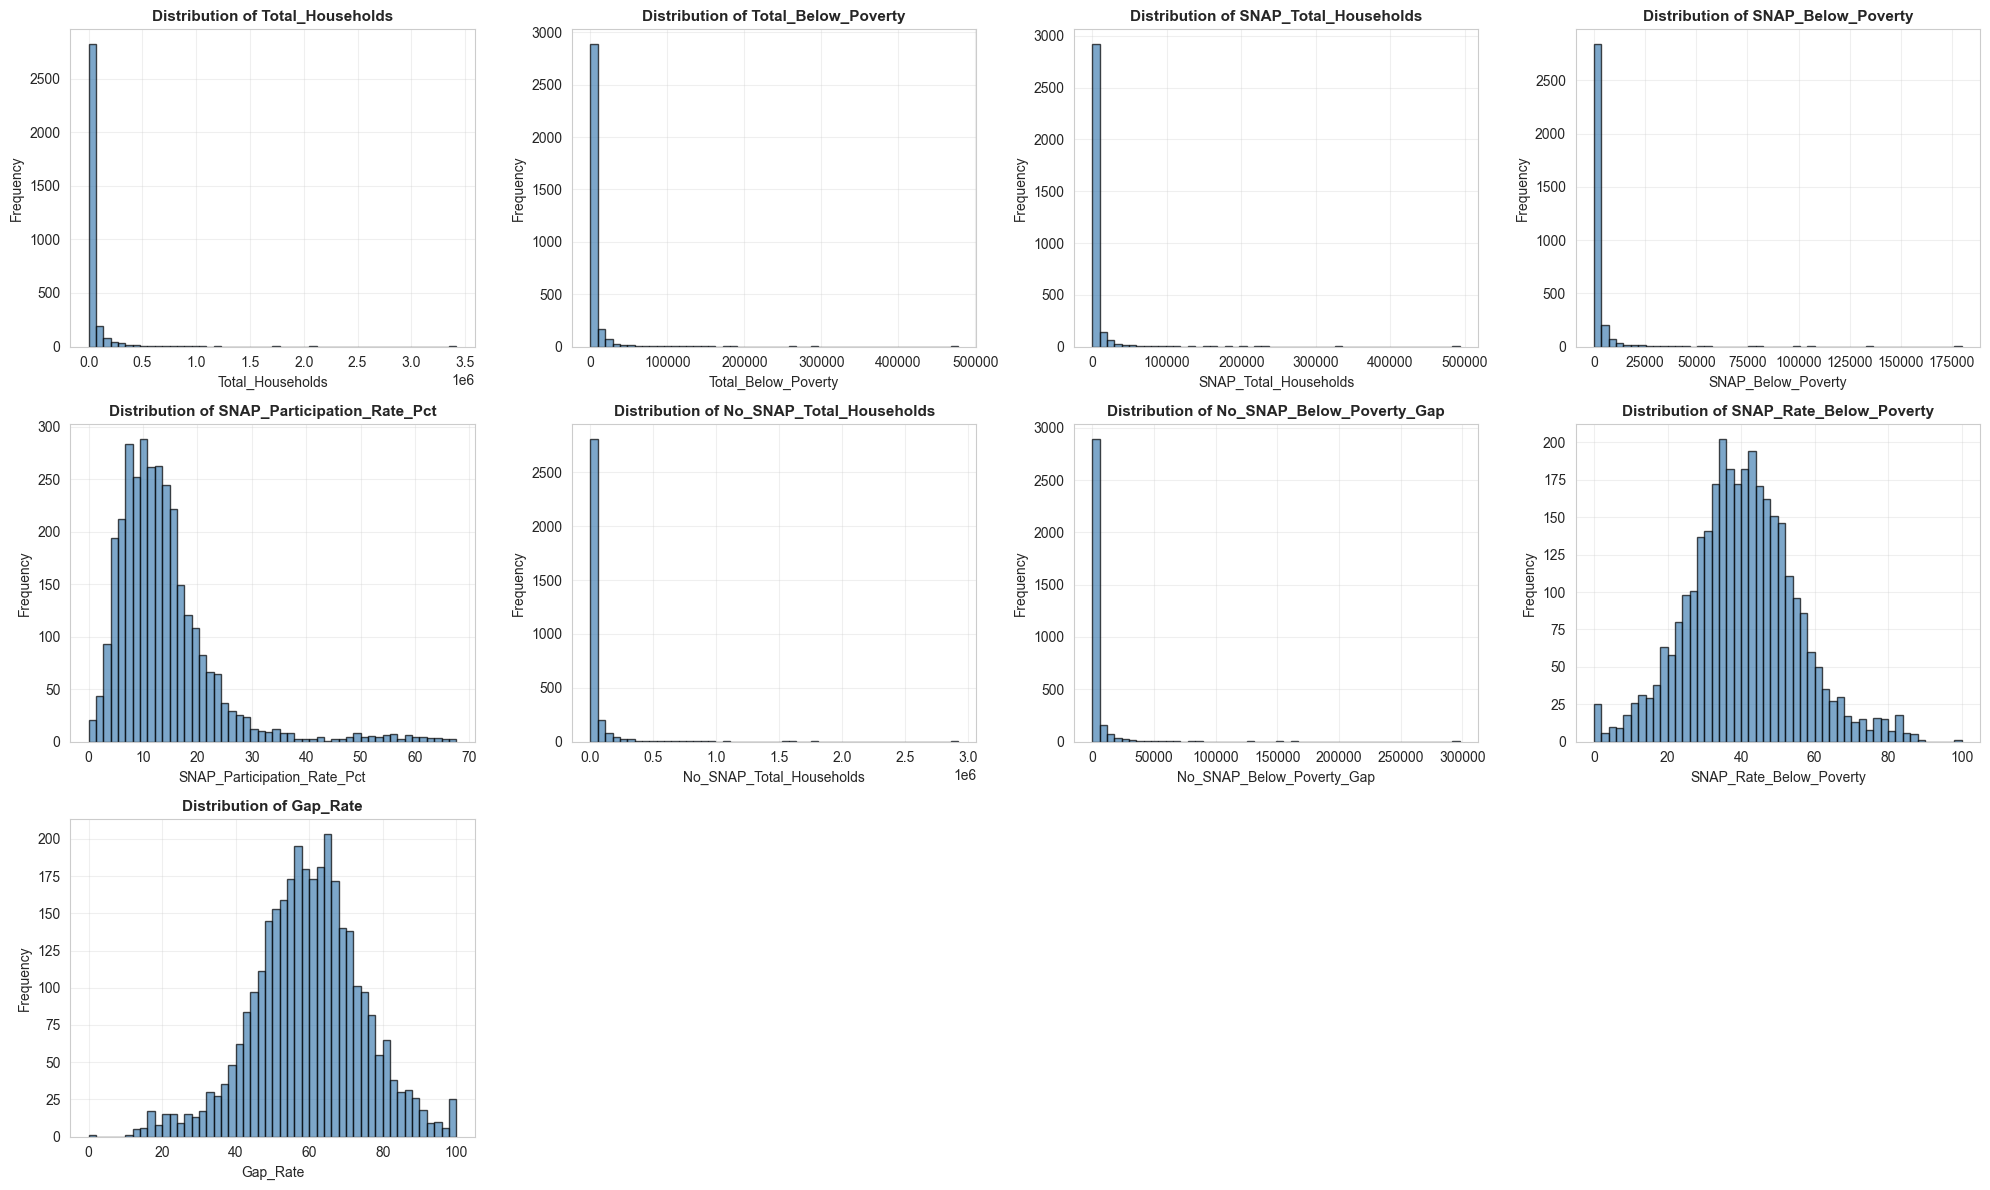

In [87]:
# Distribution plots
numeric_cols = df_snap.select_dtypes(include=[np.number]).columns
create_distribution_plots(df_snap, "SNAP_Gaps", numeric_cols)

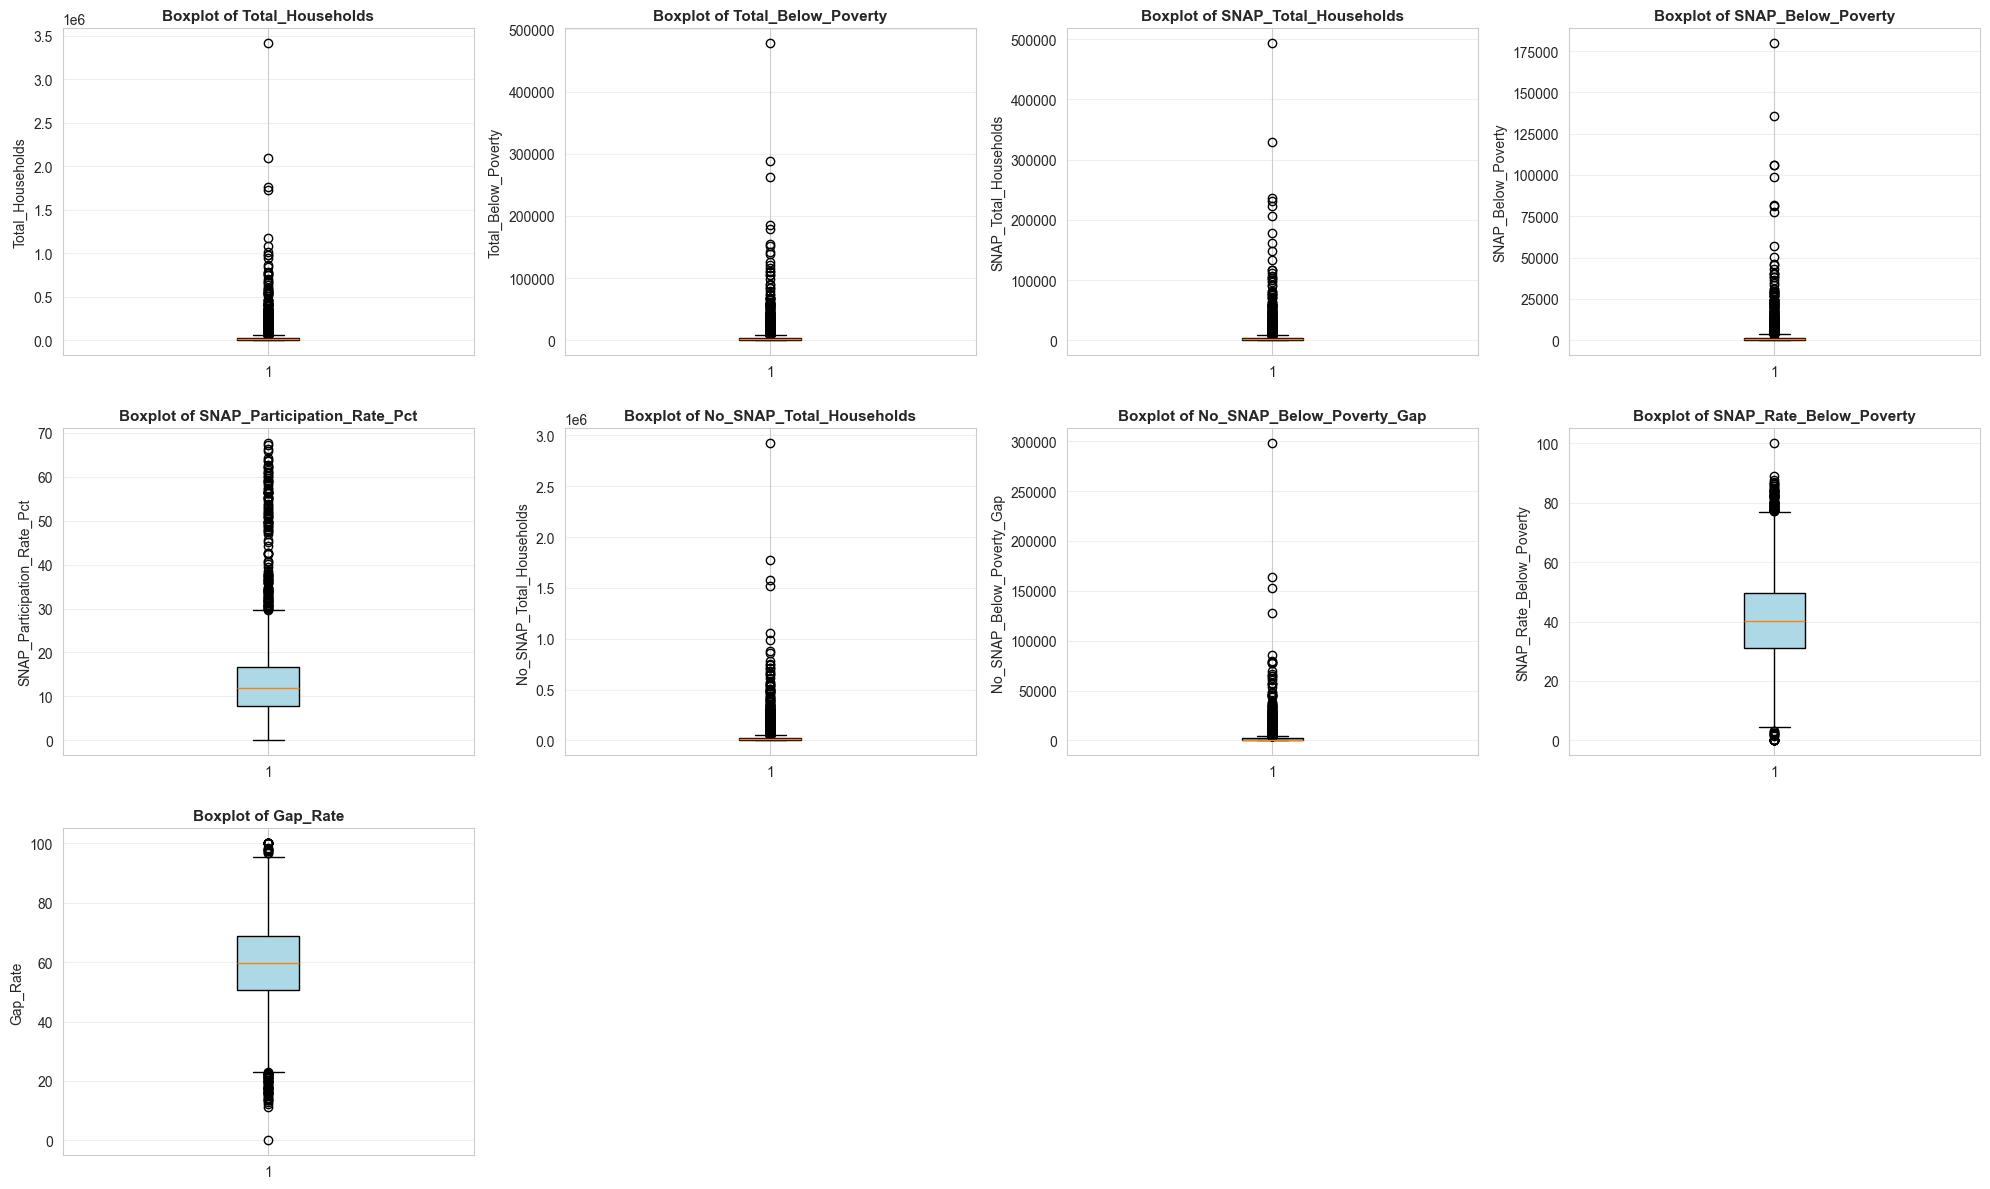

In [88]:
# Boxplots
create_boxplots(df_snap, "SNAP_Gaps", numeric_cols)


SNAP Gaps - Correlation Analysis
------------------------------------------------------------

Correlation Matrix:


,Total_Households,Total_Below_Poverty,SNAP_Total_Households,SNAP_Below_Poverty,SNAP_Participation_Rate_Pct,No_SNAP_Total_Households,No_SNAP_Below_Poverty_Gap,SNAP_Rate_Below_Poverty,Gap_Rate
Total_Households,1.00,0.96,0.93,0.89,-0.05,1.00,0.98,-0.04,0.04
Total_Below_Poverty,0.96,1.00,0.98,0.97,0.04,0.95,0.98,0.03,-0.03
SNAP_Total_Households,0.93,0.98,1.00,0.99,0.07,0.91,0.95,0.07,-0.07
SNAP_Below_Poverty,0.89,0.97,0.99,1.00,0.11,0.86,0.91,0.11,-0.11
SNAP_Participation_Rate_Pct,-0.05,0.04,0.07,0.11,1.00,-0.06,-0.02,0.80,-0.80
No_SNAP_Total_Households,1.00,0.95,0.91,0.86,-0.06,1.00,0.98,-0.05,0.05
No_SNAP_Below_Poverty_Gap,0.98,0.98,0.95,0.91,-0.02,0.98,1.00,-0.03,0.03
SNAP_Rate_Below_Poverty,-0.04,0.03,0.07,0.11,0.80,-0.05,-0.03,1.00,-1.00
Gap_Rate,0.04,-0.03,-0.07,-0.11,-0.80,0.05,0.03,-1.00,1.00


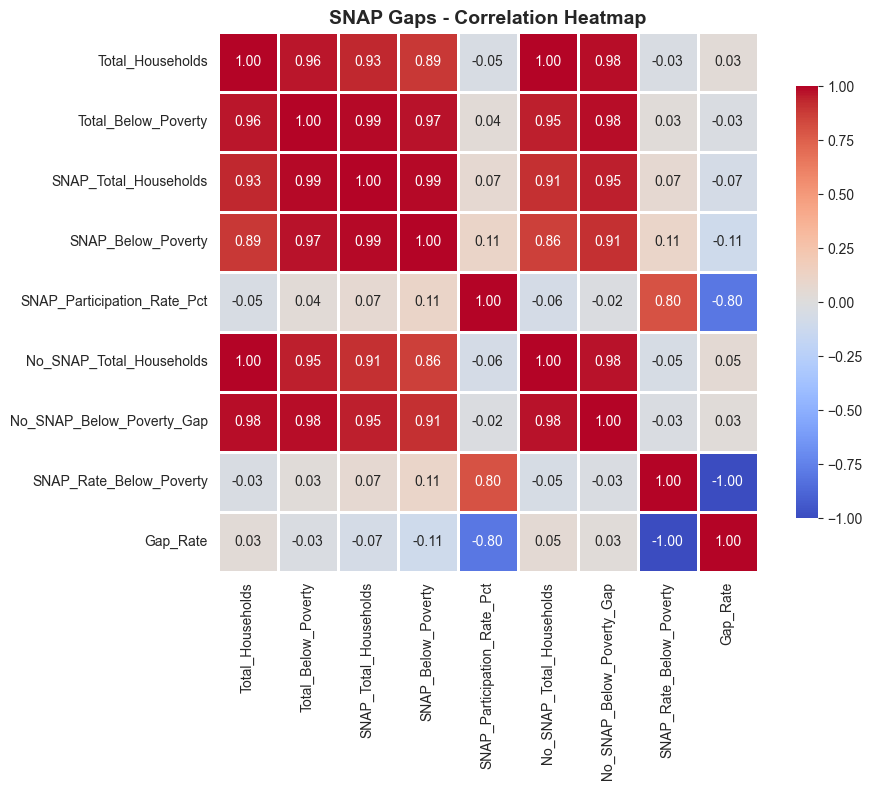



Highly Correlated Variable Pairs (|r| > 0.7):


,Variable 1,Variable 2,Correlation
17,SNAP_Rate_Below_Poverty,Gap_Rate,-1.00
3,Total_Households,No_SNAP_Total_Households,1.00
9,SNAP_Total_Households,SNAP_Below_Poverty,0.99
5,Total_Below_Poverty,SNAP_Total_Households,0.99
8,Total_Below_Poverty,No_SNAP_Below_Poverty_Gap,0.98
4,Total_Households,No_SNAP_Below_Poverty_Gap,0.98
16,No_SNAP_Total_Households,No_SNAP_Below_Poverty_Gap,0.98
6,Total_Below_Poverty,SNAP_Below_Poverty,0.97
0,Total_Households,Total_Below_Poverty,0.96
7,Total_Below_Poverty,No_SNAP_Total_Households,0.95


In [90]:
# Correlation analysis
correlation_analysis(df_snap, "SNAP Gaps")

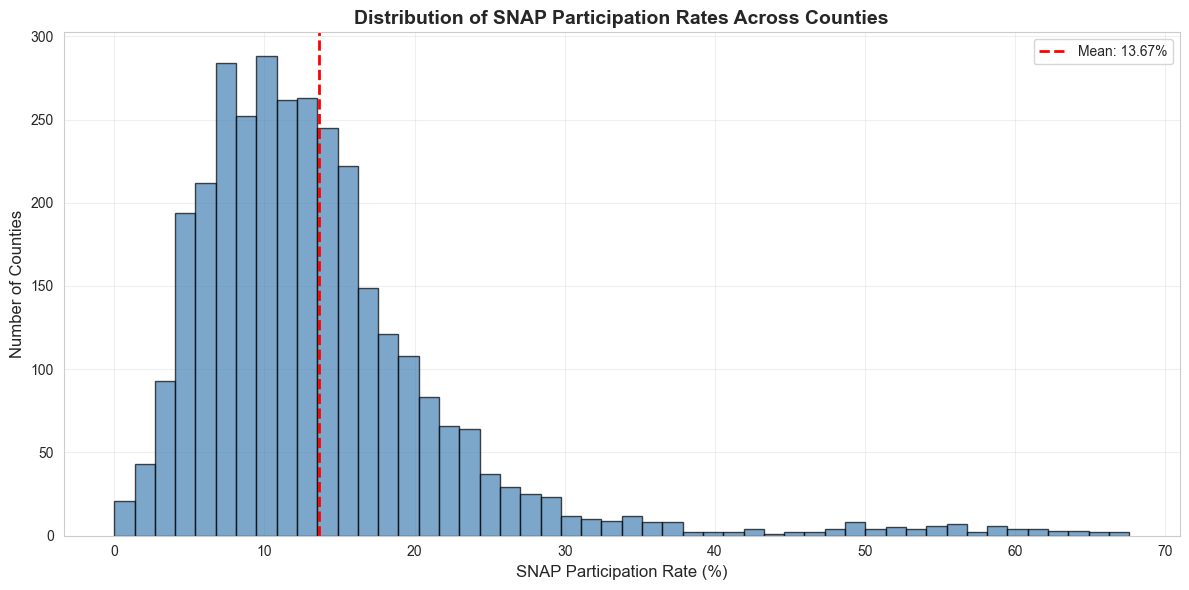

In [92]:
# Participation rate distribution
plt.figure(figsize=(12, 6))
plt.hist(df_snap['SNAP_Participation_Rate_Pct'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel('SNAP Participation Rate (%)', fontsize=12)
plt.ylabel('Number of Counties', fontsize=12)
plt.title('Distribution of SNAP Participation Rates Across Counties', fontsize=14, fontweight='bold')
plt.axvline(df_snap['SNAP_Participation_Rate_Pct'].mean(), color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {df_snap["SNAP_Participation_Rate_Pct"].mean():.2f}%')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

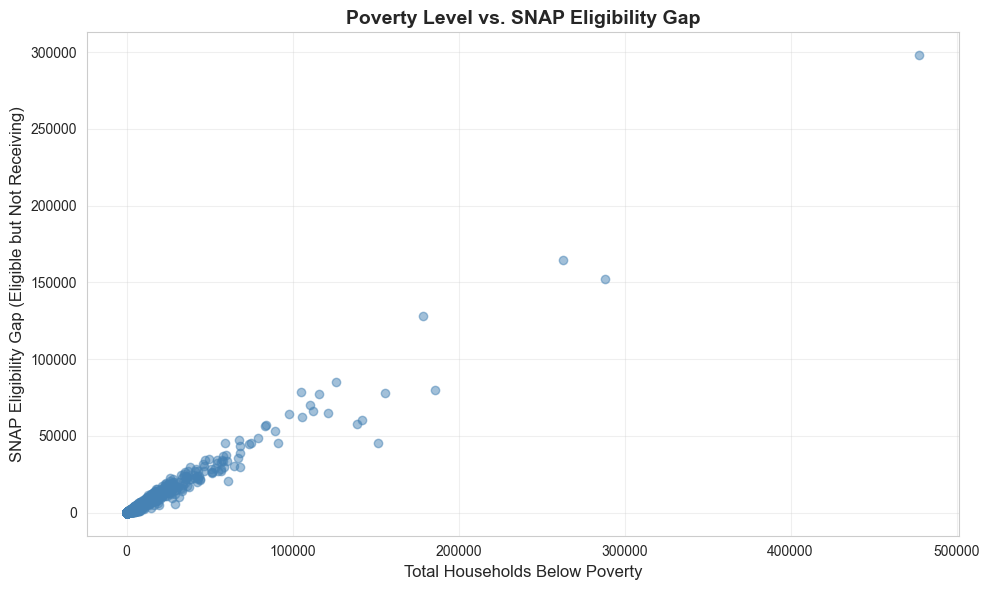

In [93]:
# Scatter plot: Poverty vs Gap
plt.figure(figsize=(10, 6))
plt.scatter(df_snap['Total_Below_Poverty'], df_snap['No_SNAP_Below_Poverty_Gap'], alpha=0.5, color='steelblue')
plt.xlabel('Total Households Below Poverty', fontsize=12)
plt.ylabel('SNAP Eligibility Gap (Eligible but Not Receiving)', fontsize=12)
plt.title('Poverty Level vs. SNAP Eligibility Gap', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
# Summary and Next Steps

In [100]:
print("\n" + "="*80)
print(" EDA COMPLETE - SUMMARY")
print("="*80)
print("\nAll individual EDAs have been completed successfully!")
print("\n\nNext Steps for Your Research Project:")
print("-" * 60)
print("1. Review missing data patterns and decide on imputation strategies")
print("2. Address outliers identified in the analysis")
print("3. Consider data merging strategy (FIPS codes for joining)")
print("4. Plan feature engineering for representation learning")
print("5. Design spatial weighting scheme for regional spillover effects")
print("6. Implement state-level fixed effects in modeling framework")
print("7. Prepare data for autoencoder/NMF representation learning")
print("8. Set up spatial block cross-validation strategy")
print("\n" + "="*80)
print(" Analysis Complete!")
print("="*80)


 EDA COMPLETE - SUMMARY

All individual EDAs have been completed successfully!


Next Steps for Your Research Project:
------------------------------------------------------------
1. Review missing data patterns and decide on imputation strategies
2. Address outliers identified in the analysis
3. Consider data merging strategy (FIPS codes for joining)
4. Plan feature engineering for representation learning
5. Design spatial weighting scheme for regional spillover effects
6. Implement state-level fixed effects in modeling framework
7. Prepare data for autoencoder/NMF representation learning
8. Set up spatial block cross-validation strategy

 Analysis Complete!
